<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Data Science and Business Analytics</font></center>
<center><font size=6>Ensemble Techniques and Model Tuning</font></center>

<center><img src="https://images.pexels.com/photos/7235894/pexels-photo-7235894.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=2" width="800" height="500"></center>

<center><font size=6>Visa Approval Facilitation</font></center>

# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Note: This is a sample solution for the project. Projects will NOT be graded on the basis of how well the submission matches this sample solution. Projects will be graded on the basis of the rubric only.

# **Importing necessary libraries**

In [ ]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Library to split data
from sklearn.model_selection import train_test_split

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.model_selection import GridSearchCV

# **Loading the dataset**

In [ ]:
visa=pd.read_csv('EasyVisa.csv')

In [ ]:
visa.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [ ]:
df=visa.copy()

# **Overview of the Dataset**

* Observations

* Sanity checks

In [ ]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [ ]:
df.shape

(25480, 12)

The dataset has 25,480 number of rows and 12 columns.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


Observations:
- All columns have 25,480  non-null values, meaning at this point there are no  missing values in the dataset —We will continue analyzing the dataset.

In [ ]:
df.dtypes

,0
case_id,object
continent,object
education_of_employee,object
has_job_experience,object
requires_job_training,object
no_of_employees,int64
yr_of_estab,int64
region_of_employment,object
prevailing_wage,float64
unit_of_wage,object


Observations:
-There are 3 numerical columns ( Float and Int64 ) in the data and 9 object type columns.

In [ ]:
#checking missing values
df.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


Observations:
- No missing values.

In [ ]:
#Checking duplicates
df.duplicated().sum()

np.int64(0)

Observations:
- No duplicated values.

In [ ]:
#cheching for negative numbers
df.select_dtypes(exclude='object').lt(0).sum()

,0
no_of_employees,33
yr_of_estab,0
prevailing_wage,0


Observations:
- No of employees column has 33 negative values.

# <a name='link2'>**Exploratory Data Analysis (EDA)**</a>

In [ ]:
#viewing the rows with negative numbers for no of employees
df[df['no_of_employees'].lt(0)]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
245,EZYV246,Europe,Master's,N,N,-25,1980,Northeast,39452.9900,Year,Y,Certified
378,EZYV379,Asia,Bachelor's,N,Y,-11,2011,Northeast,32506.1400,Year,Y,Denied
832,EZYV833,South America,Master's,Y,N,-17,2002,South,129701.9400,Year,Y,Certified
2918,EZYV2919,Asia,Master's,Y,N,-26,2005,Midwest,112799.4600,Year,Y,Certified
6439,EZYV6440,Asia,Bachelor's,N,N,-14,2013,South,103.9700,Hour,Y,Denied
6634,EZYV6635,Asia,Bachelor's,Y,N,-26,1923,West,5247.3200,Year,Y,Denied
7224,EZYV7225,Europe,Doctorate,N,N,-25,1998,Midwest,141435.9500,Year,Y,Certified
7281,EZYV7282,Asia,High School,N,N,-14,2000,Midwest,58488.5000,Year,Y,Denied
7318,EZYV7319,Asia,Bachelor's,Y,Y,-26,2006,South,115005.6100,Year,Y,Certified
7761,EZYV7762,Asia,Master's,N,N,-11,2009,Midwest,38457.5100,Year,Y,Certified


Observations:

- We will consider the 33 observations as data entry errors and take the absolute values for this column.

In [ ]:
## taking the absolute values for number of employees
df['no_of_employees']=df['no_of_employees'].abs()

In [ ]:
df[df['no_of_employees'].lt(0)]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status


In [ ]:
# Making a list of all categorical variables
cat_col = list(df.select_dtypes(include="object").columns)

# Printing count of each unique value in each categorical column
for column in cat_col:
    print(f"Value counts for '{column}':")
    print(df[column].value_counts(normalize=True))
    print("-" * 50)

# Check number of unique case_ids
print("Unique case_ids:", df["case_id"].nunique())

# Drop case_id column
df.drop(["case_id"], axis=1, inplace=True)


Value counts for 'case_id':
case_id
EZYV25480    0.000039
EZYV01       0.000039
EZYV02       0.000039
EZYV03       0.000039
EZYV04       0.000039
               ...   
EZYV13       0.000039
EZYV12       0.000039
EZYV11       0.000039
EZYV10       0.000039
EZYV09       0.000039
Name: proportion, Length: 25480, dtype: float64
--------------------------------------------------
Value counts for 'continent':
continent
Asia             0.661735
Europe           0.146468
North America    0.129199
South America    0.033438
Africa           0.021625
Oceania          0.007535
Name: proportion, dtype: float64
--------------------------------------------------
Value counts for 'education_of_employee':
education_of_employee
Bachelor's     0.401648
Master's       0.378100
High School    0.134223
Doctorate      0.086028
Name: proportion, dtype: float64
--------------------------------------------------
Value counts for 'has_job_experience':
has_job_experience
Y    0.580926
N    0.419074
Name: proport

Observations:

###   Observations - Categorical Variables

| Column                   | Observation |
|--------------------------|-------------|
| `case_id`                | Unique for every record. ➤ Dropped since it has no predictive value. |
| `continent`              | Dominated by **Asia** (≈66% of data).  |
| `education_of_employee` | Most applicants hold a **Bachelor’s** or **Master’s** degree.|
| `has_job_experience`     | Majority (~58%) have job experience. Binary (Y/N). |
| `requires_job_training`  | Most (~88%) **do not** require training. Binary (Y/N). |
| `region_of_employment`   | Balanced across major U.S. regions. Top regions: Northeast, South, West.  |
| `unit_of_wage`           | **Yearly** wages dominate (≈90%). Other units (Hour, Week, Month)  |
| `full_time_position`     | Most positions are **full-time** (~89%). Binary (Y/N). |
| `case_status` *(Target)* | Imbalanced: ~67% Certified vs. 33% Denied  |


## Univariate Analysis

Creating functions that will help us with further analysis.

In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="darkgrey"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, color= 'lightseagreen',alpha= 0.7
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, color= 'lightseagreen', alpha= 0.7
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
def labeled_barplot(data, feature, perc=False, n=None, hue=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column (x-axis)
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    hue: (optional) another feature to group bars (default is None)
    """

    total = len(data)  # total rows — needed for % calc
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)

    ax = sns.countplot(
        data=data,
        x=feature,
        hue=hue,
        order=data[feature].value_counts().index[:n],
        palette="Paired"
    )

    for p in ax.patches:
        if perc == True:
            height = p.get_height()
            label = "{:.1f}%".format(100 * height / total)
        else:
            label = p.get_height()

        x = p.get_x() + p.get_width() / 2
        y = p.get_height()

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )

    plt.show()

In [ ]:
def stacked_barplot(data, predictor, target, title=None):
    """
    Print counts and plot a stacked percentage bar chart with labeled segments.

    Parameters:
    - data: DataFrame
    - predictor: column to group by (x-axis)
    - target: column to stack by (e.g., booking_status)
    - title: optional plot title
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]

    # Print raw counts
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(by=sorter, ascending=False)
    print(tab1)
    print("-" * 120)

    # Normalized proportions
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(by=sorter, ascending=False)

    # Plotting
    ax = tab.plot(kind="bar", stacked=True, figsize=(count + 4, 5), color=["lightcoral", "lightgray"])

    # Axis labels and title
    plt.ylabel("Proportion", fontsize=12)
    plt.xlabel(predictor.replace("_", " ").title(), fontsize=12)
    if title:
        plt.title(title, fontsize=14, fontweight='bold')
    plt.xticks(rotation=90)
    plt.legend(title=target.replace("_", " ").title(), loc="upper left", bbox_to_anchor=(1, 1))

    # Add percentage labels on each segment
    for bar_group in ax.containers:
        for bar in bar_group:
            height = bar.get_height()
            if height > 0.03:  # Show only if at least 3%
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + height / 2,
                    f"{height:.0%}",
                    ha="center", va="center", fontsize=9, color="black"
                )

    plt.tight_layout()
    plt.show()

In [ ]:
df.columns

Index(['continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'no_of_employees', 'yr_of_estab',
       'region_of_employment', 'prevailing_wage', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   continent              25480 non-null  object 
 1   education_of_employee  25480 non-null  object 
 2   has_job_experience     25480 non-null  object 
 3   requires_job_training  25480 non-null  object 
 4   no_of_employees        25480 non-null  int64  
 5   yr_of_estab            25480 non-null  int64  
 6   region_of_employment   25480 non-null  object 
 7   prevailing_wage        25480 non-null  float64
 8   unit_of_wage           25480 non-null  object 
 9   full_time_position     25480 non-null  object 
 10  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 2.1+ MB


Observations on Continent

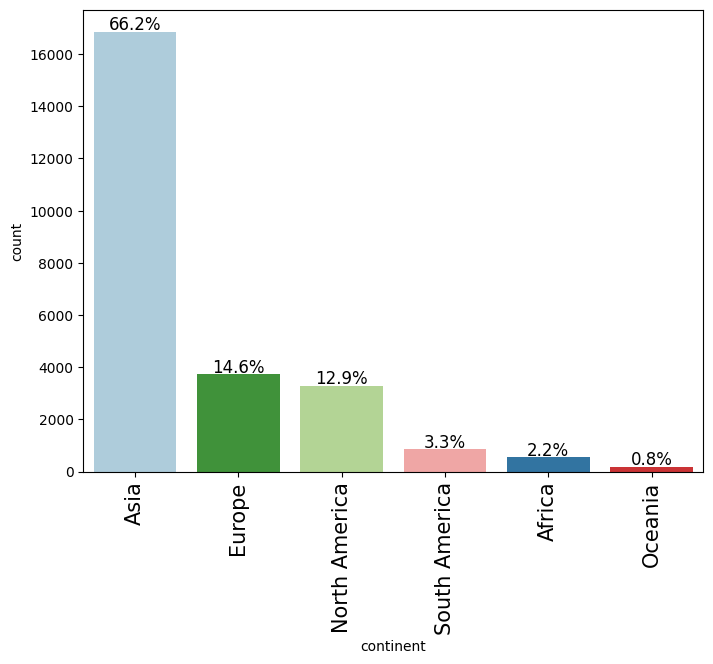

In [ ]:
#visualization of continent
labeled_barplot(df,'continent',hue='continent', perc=True)


Observations:

- Dominated by Asia (66%) — potential for geographic bias.

Observations on education_of_employee

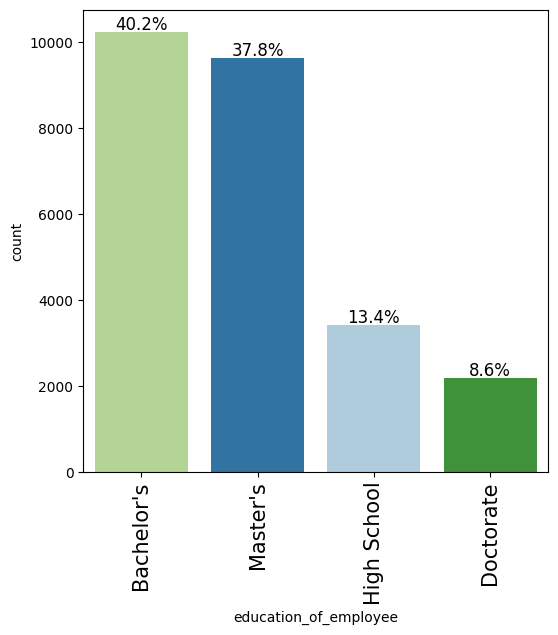

In [ ]:
#visualization of continent
labeled_barplot(df,'education_of_employee',hue='education_of_employee', perc=True)

Obervations:

-	Bachelor's (40.2%) and Master's (37.8%) degrees are most common.

Observations on has_job_experience

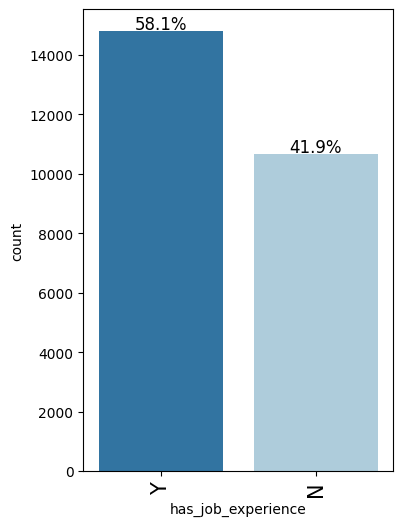

In [ ]:
labeled_barplot(df,'has_job_experience',hue='has_job_experience', perc=True)

Observations:

- 58.1% of applicants have job experience.

Observations on requires_job_training

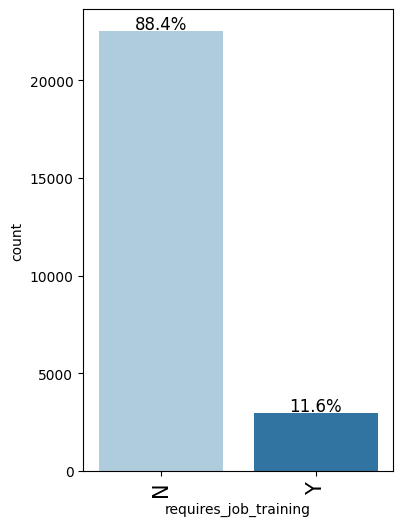

In [ ]:
labeled_barplot(df,'requires_job_training',hue='requires_job_training', perc=True)

Observations:

- 88.4% do not require job training — highly imbalanced.

Observations on no_of_employees

In [ ]:
df['no_of_employees'].value_counts()

,count
no_of_employees,
183,18
854,16
724,16
1476,15
766,15
...,...
3711,1
16399,1
4600,1


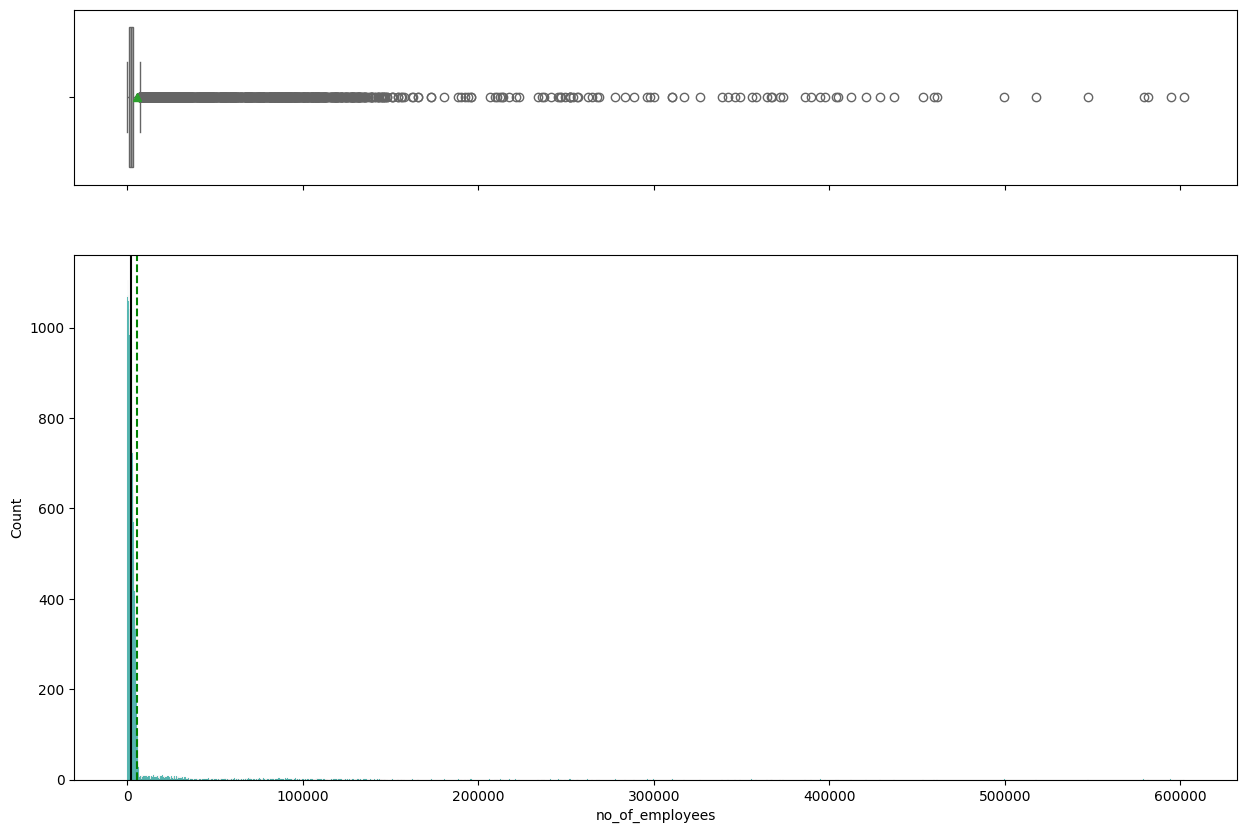

In [ ]:
#visualization for no of employees histplot
histogram_boxplot(df,'no_of_employees')


Observations:

- Extremely right-skewed with heavy outliers. Most companies have a small number of employees. Outliers reach over 600,000.

Observations on yr_of_estab

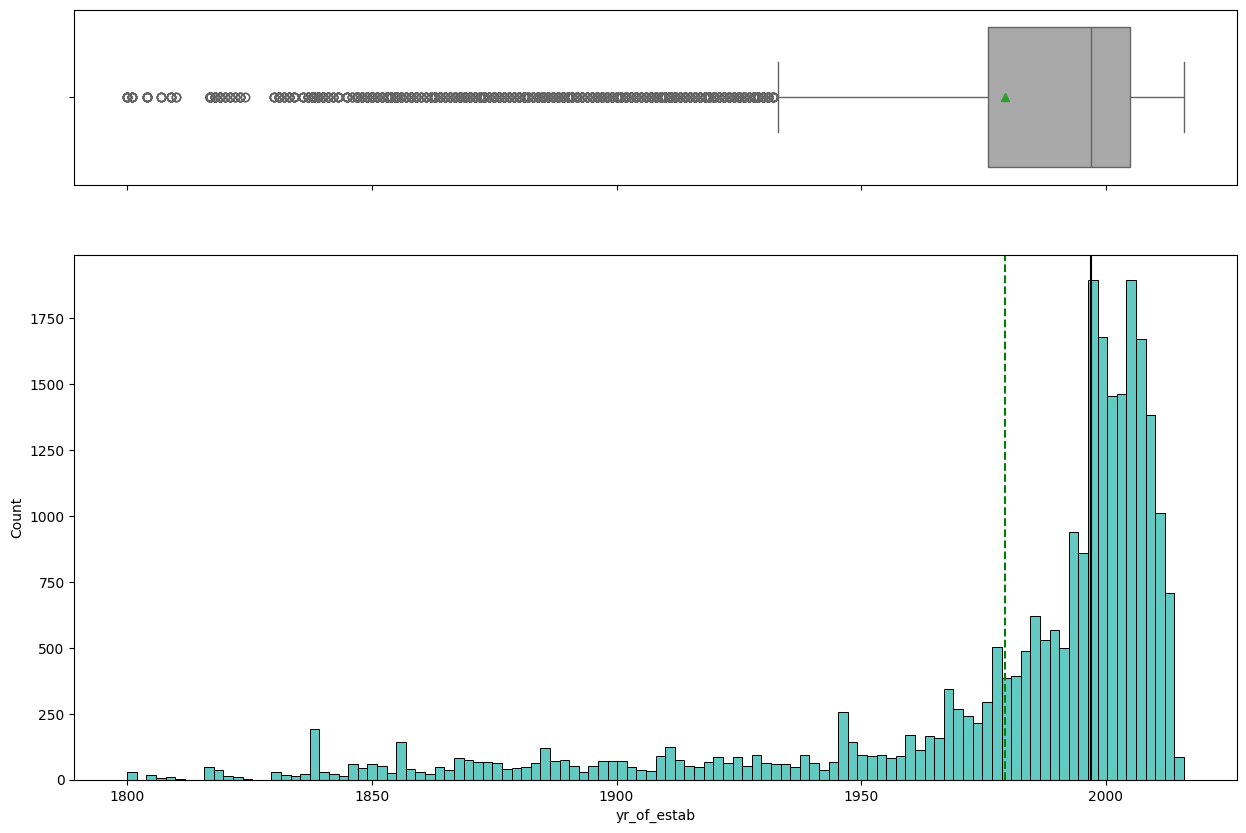

In [ ]:
histogram_boxplot(df,'yr_of_estab')

Observations:

- Slight left-skew. Most companies were established after the year 1980. A few date back to the 1800s

Observations on region_of_employment

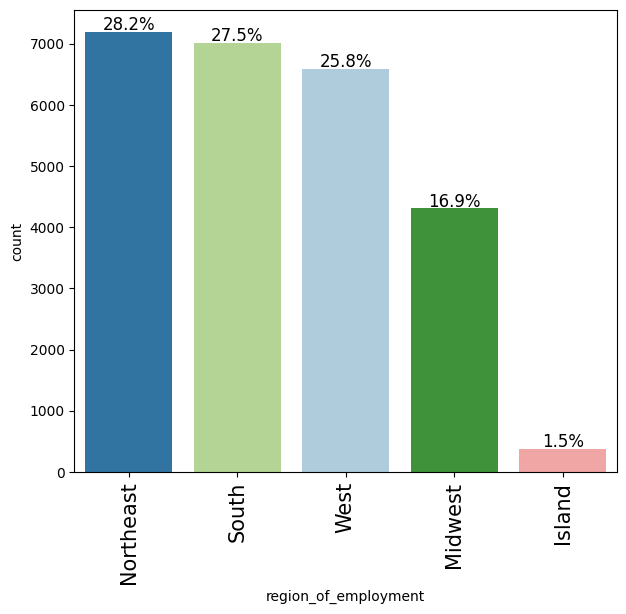

In [ ]:
labeled_barplot(df,'region_of_employment',hue='region_of_employment', perc=True)


Observations:

- Northeast (28.2%) and South (27.5%) are top regions; Island region is 1.5%.

Observations on prevailing_wage

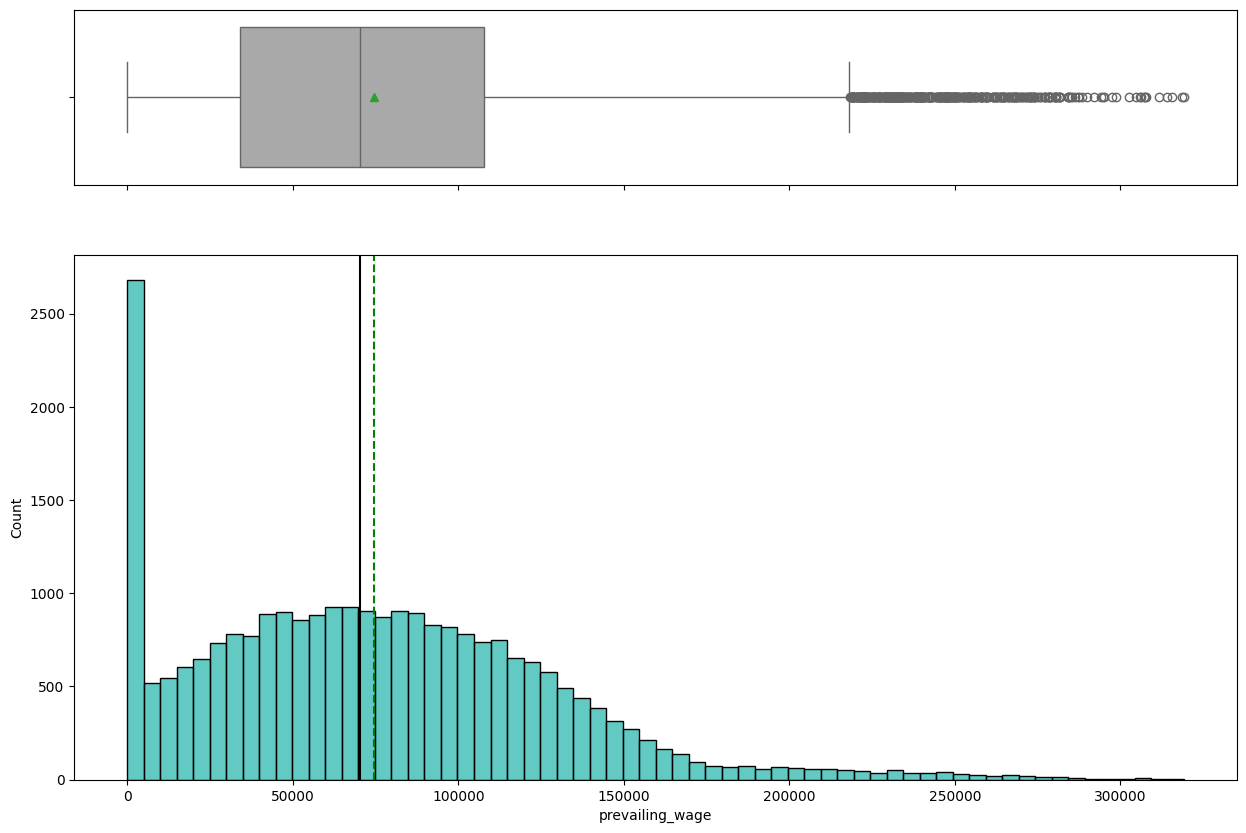

In [ ]:
histogram_boxplot(df,'prevailing_wage')

Observations:

- Right-skewed with long tail. Majority of wages are under $150,000 but extreme outliers exist. Mean > median.

Observations on unit_of_wage

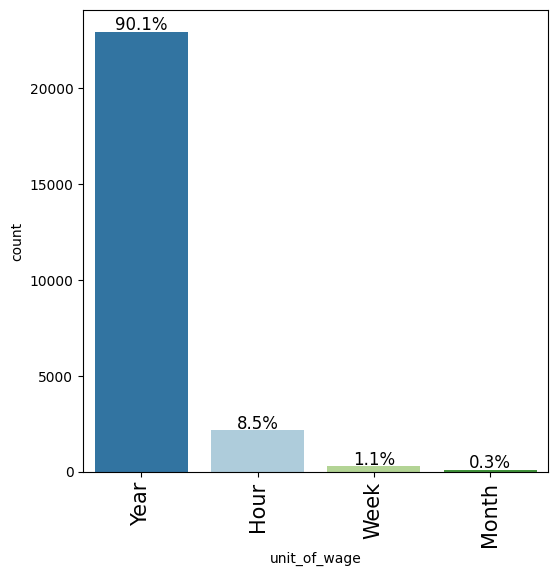

In [ ]:

labeled_barplot(df,'unit_of_wage',hue='unit_of_wage', perc=True)

Observations:

- 	90.1% of wages are Yearly — may convert others to this for consistency

Observations on full_time_position

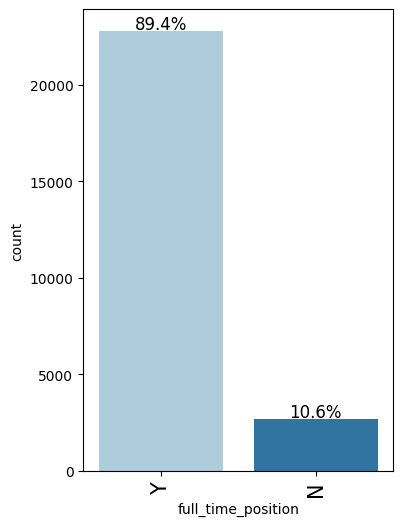

In [ ]:

labeled_barplot(df,'full_time_position',hue='full_time_position', perc=True)

Observations:

- 	89.4% of positions are full-time and 10.6% No full time.

Observations on case_status   

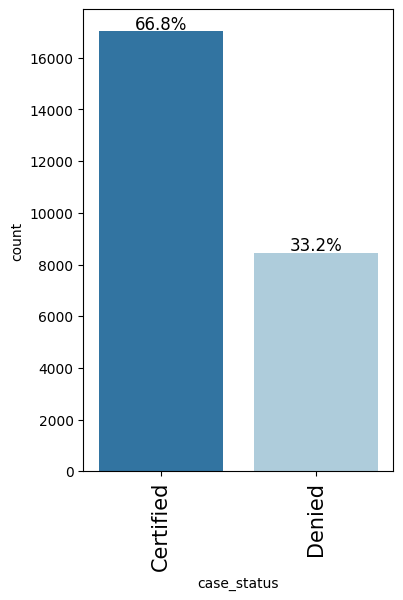

In [ ]:

labeled_barplot(df,'case_status',hue='case_status', perc=True)

Observations:

- Imbalanced target: 66.8% Certified vs 33.2% Denied.

## Bivariate Analysis

Creating functions that will help us with further analysis.

In [ ]:
#Function for plot
def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 0]
    )

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False
    )

    plt.tight_layout()
    plt.show()

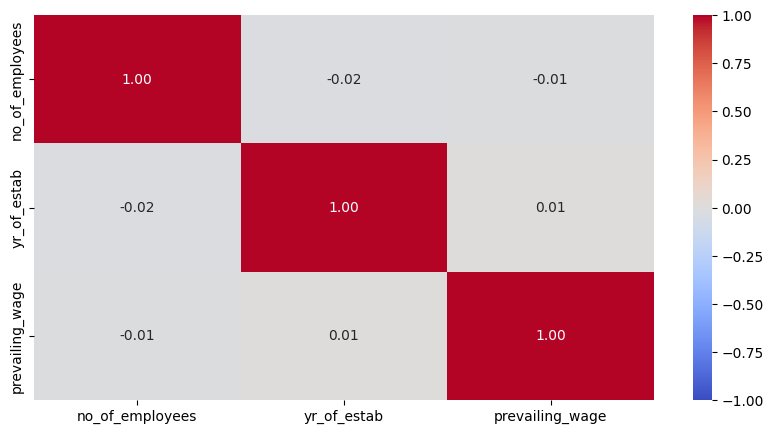

In [ ]:
#heatmap
cols_list = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    df[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="coolwarm"
)
plt.show()

Observations:

- The numerical features are independent of one another based on correlation.

- no_of_employees & yr_of_estab	Correlation -0.02.

- no_of_employees & prevailing_wage Correlation	-0.01.

- yr_of_estab & prevailing_wage Correlation	0.01.



Observations Status by Continent

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


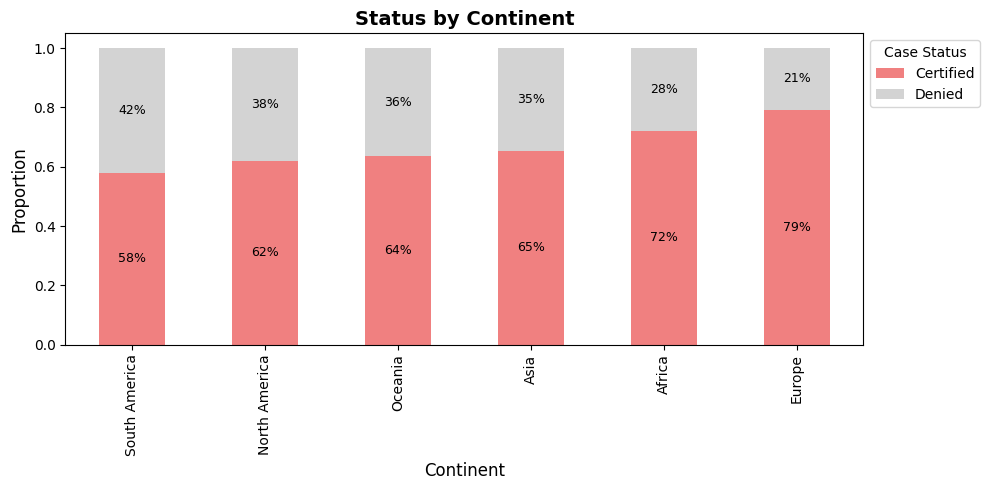

In [ ]:
stacked_barplot(df,'continent','case_status',title="Status by Continent")

Observations:

- Europe has the highest approval rate (79%), followed by Africa (72%) and Asia (65%).

Observations Status by education_of_employee

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


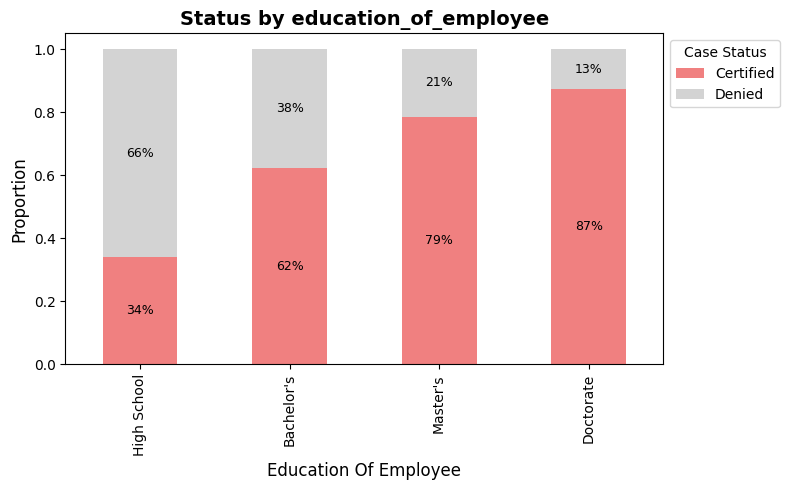

In [ ]:
stacked_barplot(df,'education_of_employee','case_status',title="Status by education_of_employee")

Observations:

- Approval rate increases with education level: Doctorate (87%) > Master's (79%) > Bachelor's (62%) > High School (34%).

Observation Status by has_job_experience

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


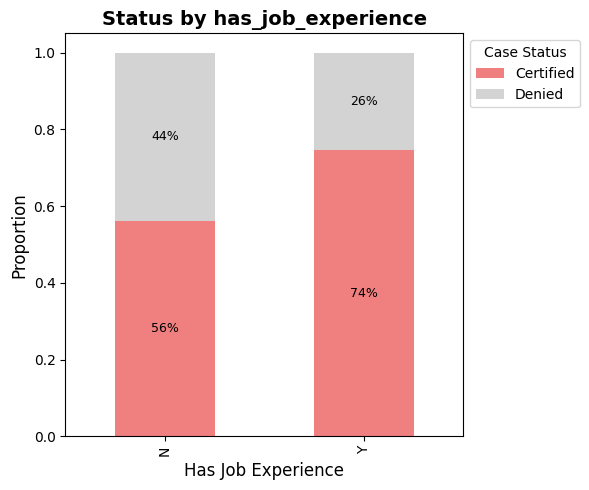

In [ ]:
stacked_barplot(df,'has_job_experience','case_status',title="Status by has_job_experience")

Observations:

- Job experience increases chances: Yes (74%) vs No (56%).

Observations Status by requires_job_training

case_status            Certified  Denied    All
requires_job_training                          
All                        17018    8462  25480
N                          15012    7513  22525
Y                           2006     949   2955
------------------------------------------------------------------------------------------------------------------------


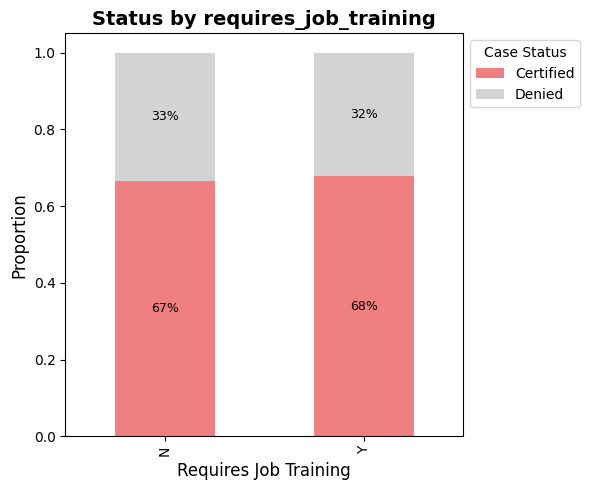

In [ ]:
stacked_barplot(df,'requires_job_training','case_status',title="Status by requires_job_training")

Observations:

- Little difference: both Y and N cases show similar approval rates (~67%) - (~68%).

Observations Status by region_of_employment

case_status           Certified  Denied    All
region_of_employment                          
All                       17018    8462  25480
Northeast                  4526    2669   7195
West                       4100    2486   6586
South                      4913    2104   7017
Midwest                    3253    1054   4307
Island                      226     149    375
------------------------------------------------------------------------------------------------------------------------


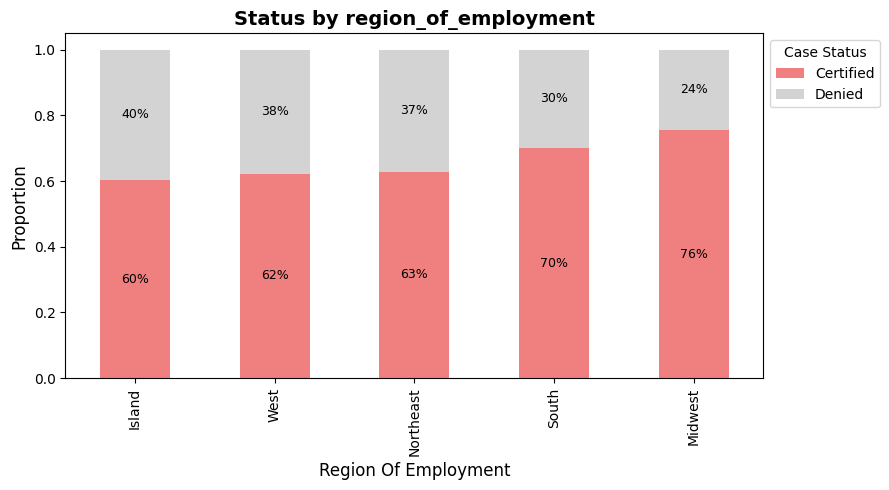

In [ ]:
stacked_barplot(df,'region_of_employment','case_status',title="Status by region_of_employment")

Observations:

- Midwest and South have higher approval rates (~76–70%) than Island or West (~60%).

Observations Stauts by unit_of_wage

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


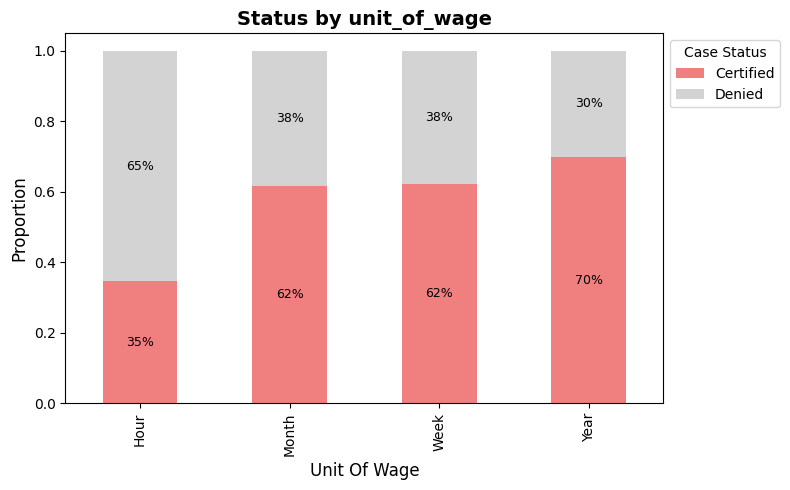

In [ ]:
stacked_barplot(df,'unit_of_wage','case_status',title="Status by unit_of_wage")

Observations:

- Yearly wage unit has highest approval (70%), while Hourly is lowest (35%).

Observations Status by full_time_position

case_status         Certified  Denied    All
full_time_position                          
All                     17018    8462  25480
Y                       15163    7610  22773
N                        1855     852   2707
------------------------------------------------------------------------------------------------------------------------


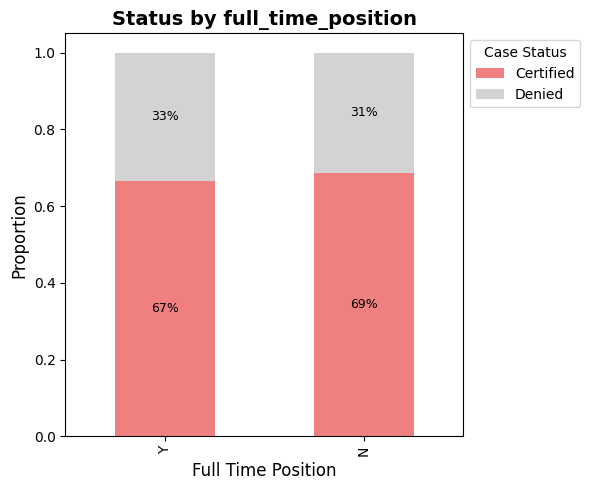

In [ ]:
stacked_barplot(df,'full_time_position','case_status',title="Status by full_time_position")

Observations:

- Slightly higher approval for part-time (69%) than full-time (67%), but the majority of jobs are full-time.

Checking if the prevailing wage is similar across all the regions of the US

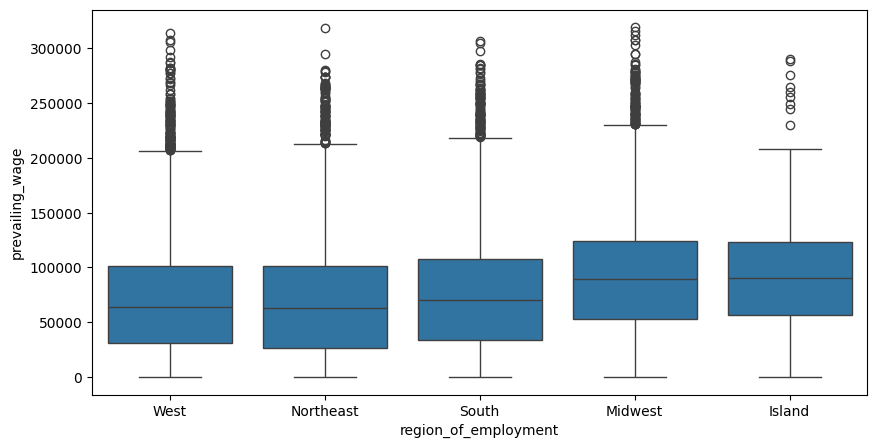

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="region_of_employment", y="prevailing_wage")
plt.show()

Observations:

- 	All regions show right-skewed distributions with significant outliers above $200,000.

- The median prevailing wage increases slightly from West → Island. Midwest and Island regions appear to have slightly higher medians.

- 	All regions have a high number of wage outliers, suggesting some job roles or industries with significantly higher pay.

Let's analyze the data and see if the visa status changes with the prevailing wage

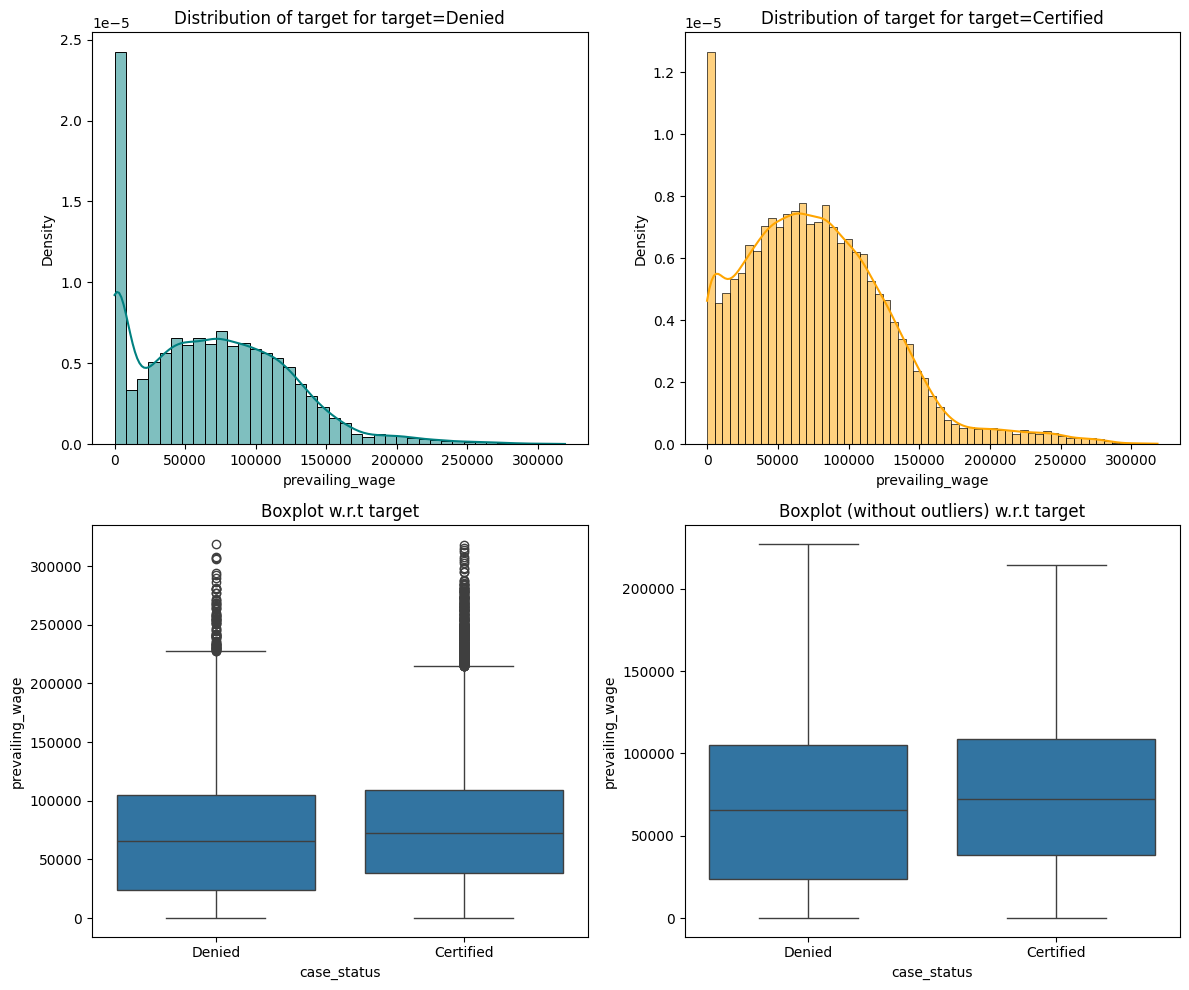

In [ ]:
distribution_plot_wrt_target(df, "prevailing_wage", "case_status")

Observations:

- Most denied applications cluster around lower wages (< $50K). Sharp peak on the low end.

- Wage distribution is broader, with a noticeable right skew, and the peak around $60K–$100K.

Observations on no_of_employees and case_status

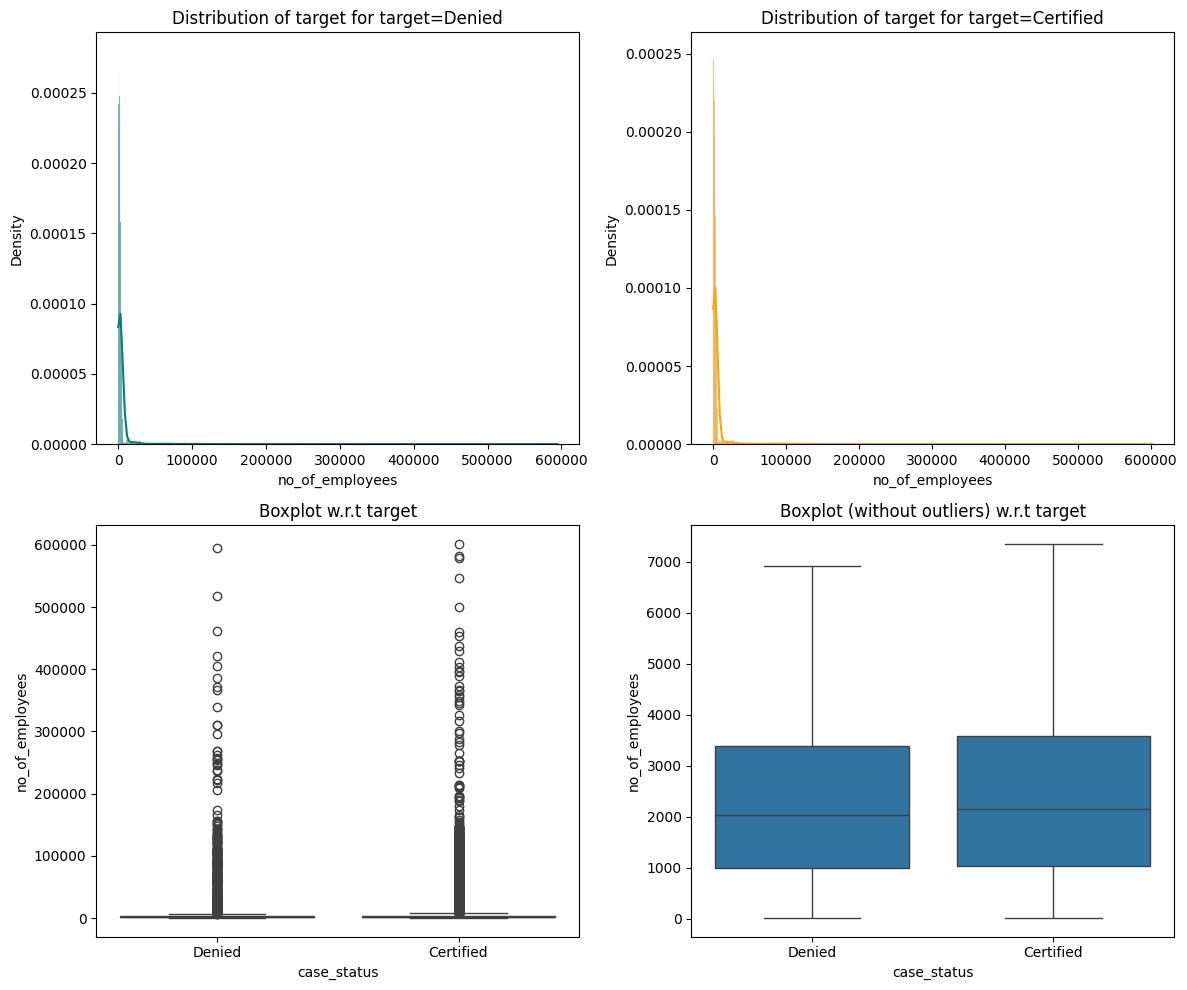

In [ ]:
distribution_plot_wrt_target(df, "no_of_employees", "case_status")

Observations:

- Highly right-skewed. Most applications come from companies with few employees (<10,000). A few extreme outliers.



Observations on yr_of_estab and case_status

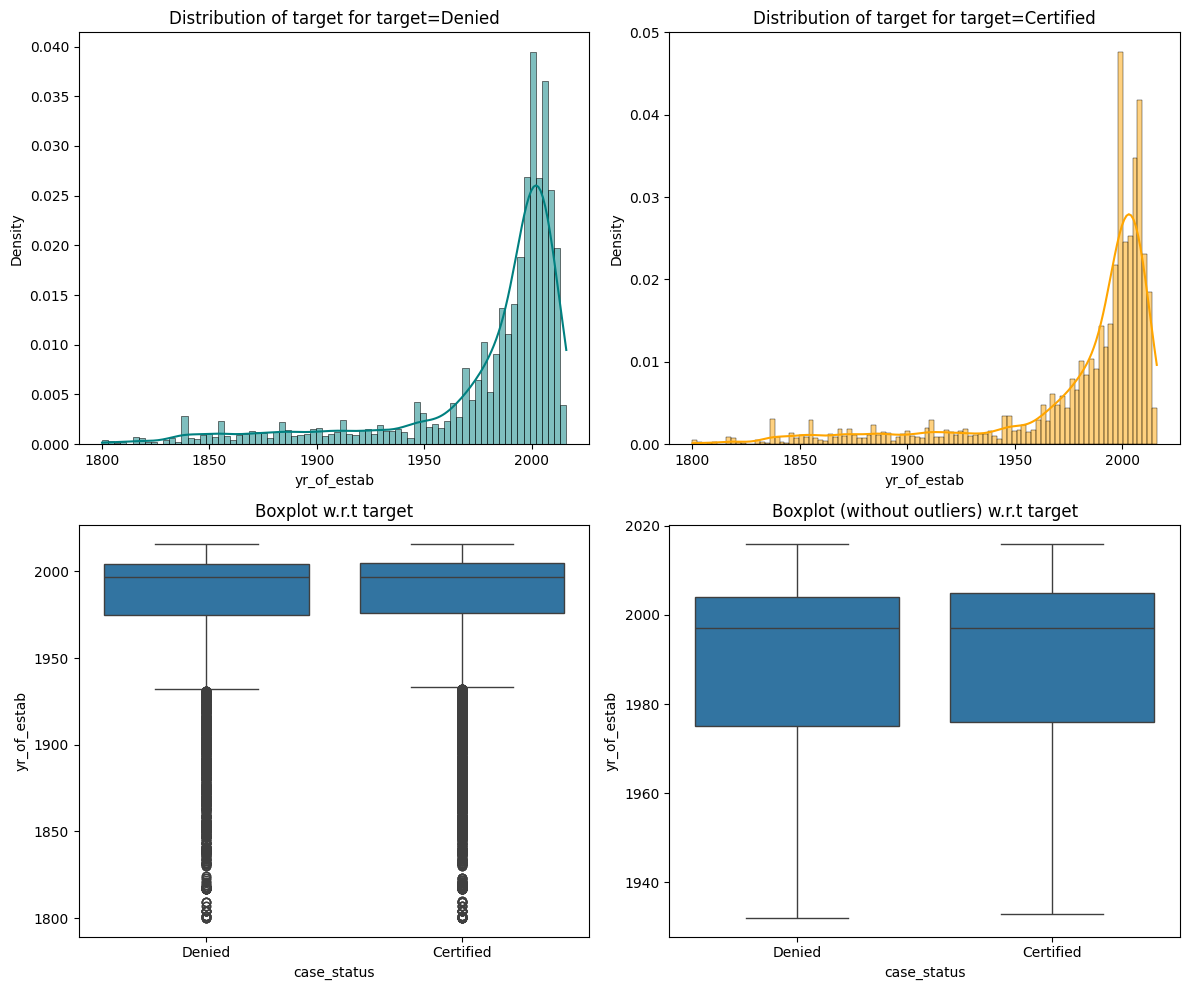

In [ ]:
distribution_plot_wrt_target(df, "yr_of_estab", "case_status")

Observations:

- Most applications are from companies established after 1980, peaking around 2000–2010.

- Both Certified and Denied applications include companies established as early as 1800s.

- Older companies slightly more likely to get Certified, but not a dominant pattern.

## Leading Questions

1. What is the distribution of visa case statuses (certified vs. denied)?
2. How does the education level of employees impact visa approval rates?
3. Is there a significant difference in visa approval rates between employees with and without prior job experience?
4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?
5. Do certain regions in the US have higher visa approval rates compared to others?
6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?
7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?

###**1. What is the distribution of visa case statuses (certified vs. denied)?**

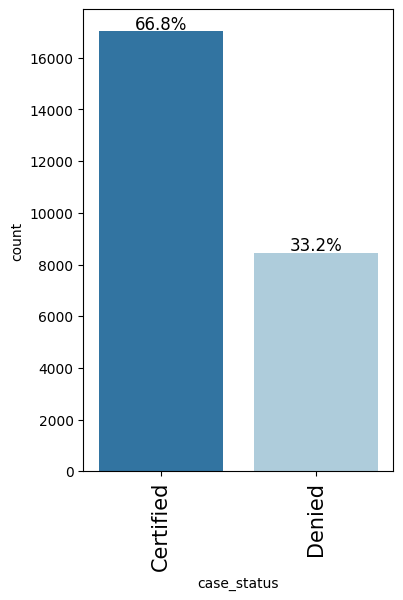

In [ ]:
labeled_barplot(df,'case_status',hue='case_status', perc=True)

Observations:

- Visa Case Status Distribution

~67% Certified, ~33% Denied

###**2. How does the education level of employees impact visa approval rates?**


case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


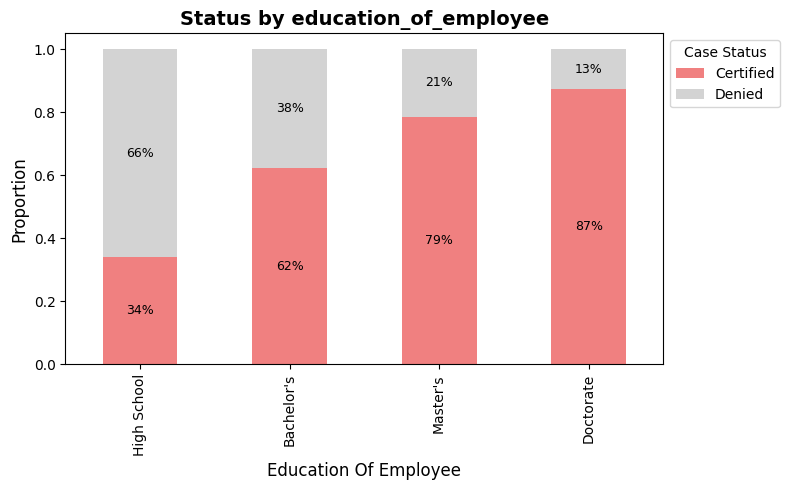

In [ ]:
stacked_barplot(df,'education_of_employee','case_status',title="Status by education_of_employee")

Observations:

- Higher education levels (Doctorate, Master’s) are linked to higher certification rates.

###**3-. Is there a significant difference in visa approval rates between employees with and without prior job experience?**


case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


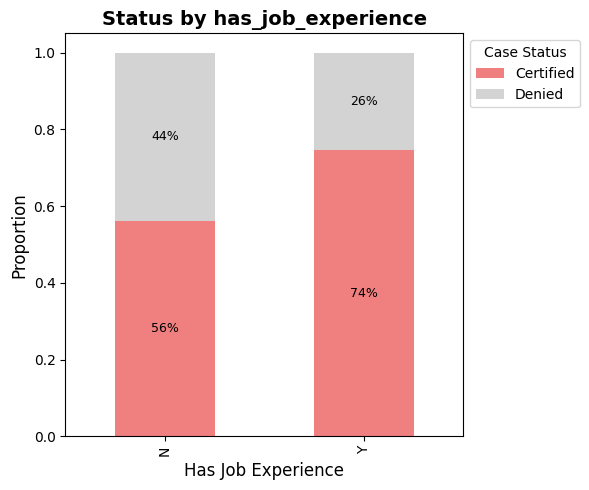

In [ ]:
stacked_barplot(df,'has_job_experience','case_status',title="Status by has_job_experience")

Observations:

- Applicants with job experience have a significantly higher approval rate

###**4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?**


In [ ]:
wage_stats = df.groupby("case_status")["prevailing_wage"].describe()
print("4. Prevailing Wage Statistics by Visa Status:")
print(wage_stats[["mean", "50%"]], "\n")

4. Prevailing Wage Statistics by Visa Status:
                     mean       50%
case_status                        
Certified    77293.619243  72486.27
Denied       68748.681580  65431.46 



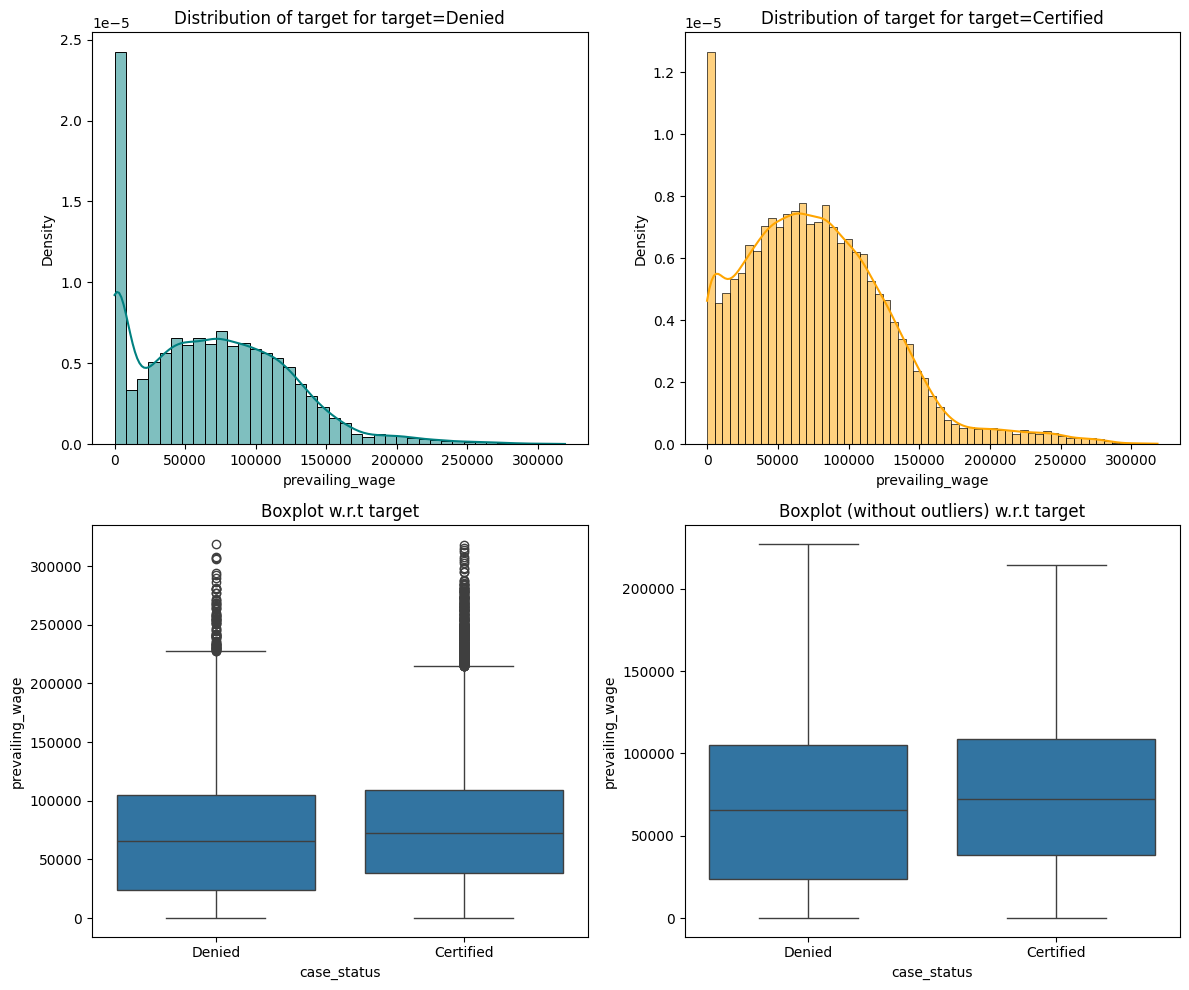

In [ ]:
distribution_plot_wrt_target(df, "prevailing_wage", "case_status")

Observations:

- Certified applications tend to have higher prevailing wages, both in central tendency and distribution spread.

- Certified cases have higher average and median wages than denied ones.

### **5. Do certain regions in the US have higher visa approval rates compared to others?**


case_status           Certified  Denied    All
region_of_employment                          
All                       17018    8462  25480
Northeast                  4526    2669   7195
West                       4100    2486   6586
South                      4913    2104   7017
Midwest                    3253    1054   4307
Island                      226     149    375
------------------------------------------------------------------------------------------------------------------------


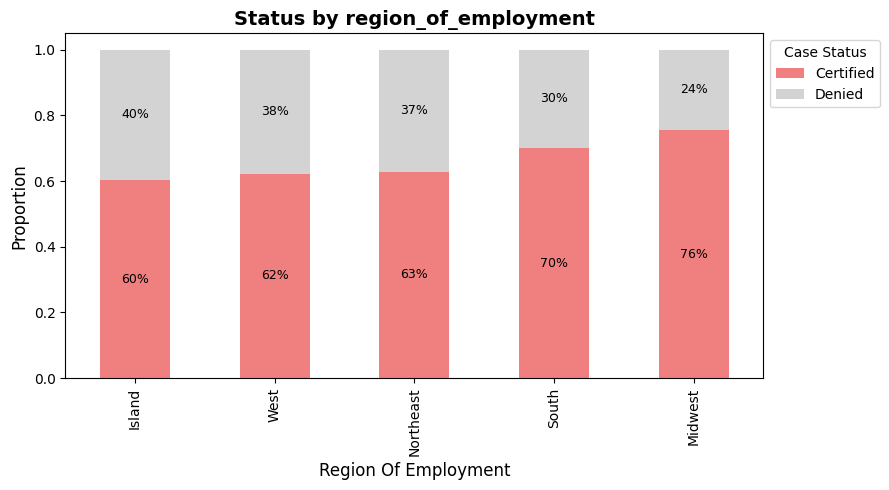

In [ ]:
stacked_barplot(df,'region_of_employment','case_status',title="Status by region_of_employment")

Observations:

- Some regions (like Midwest and South) show higher approval rates.

###**6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?**


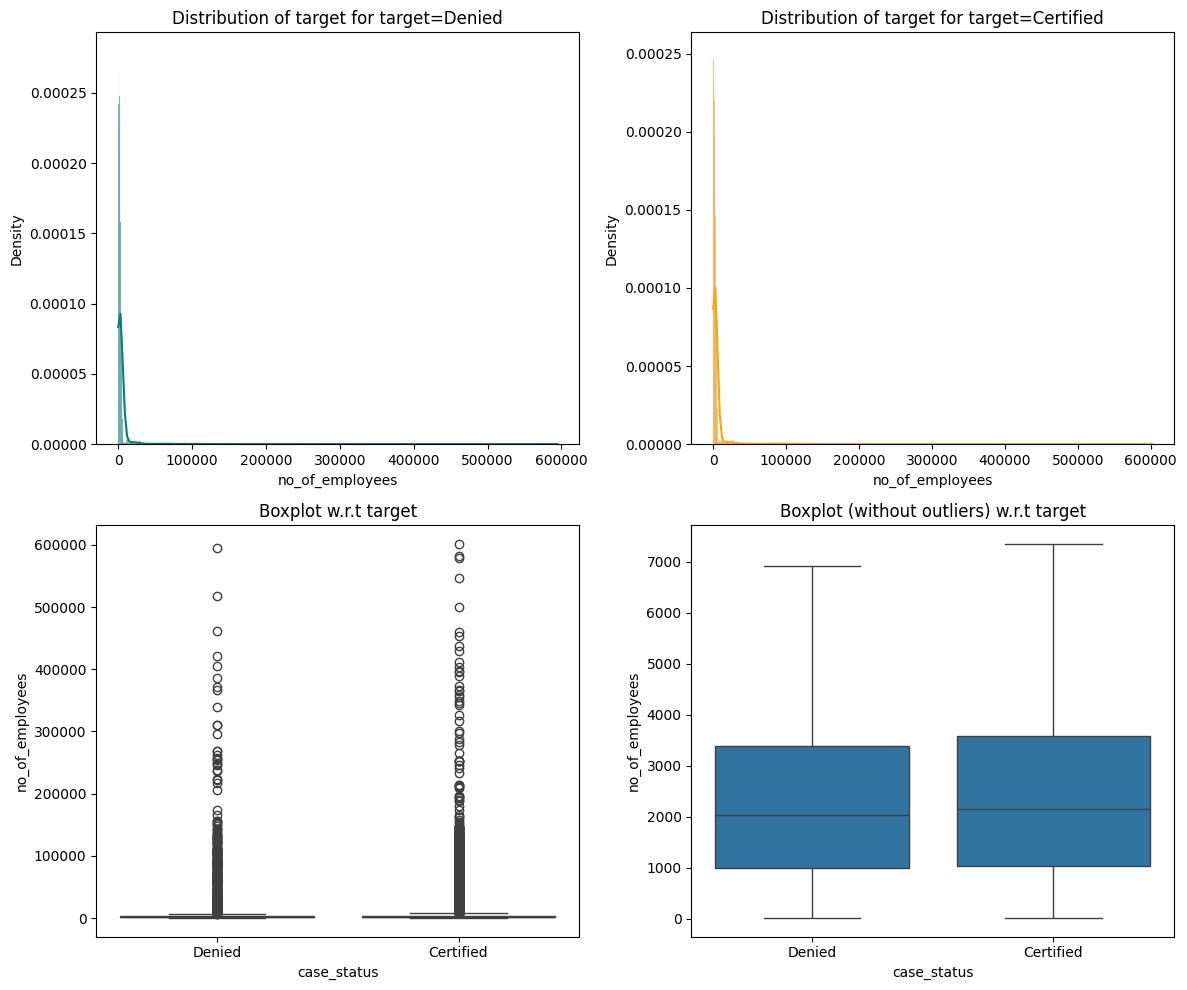

In [ ]:
distribution_plot_wrt_target(df, "no_of_employees", "case_status")

Observations:

- Larger companies (higher no_of_employees) tend to have a better approval rate, though the effect is not drastic.

### **7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?**

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


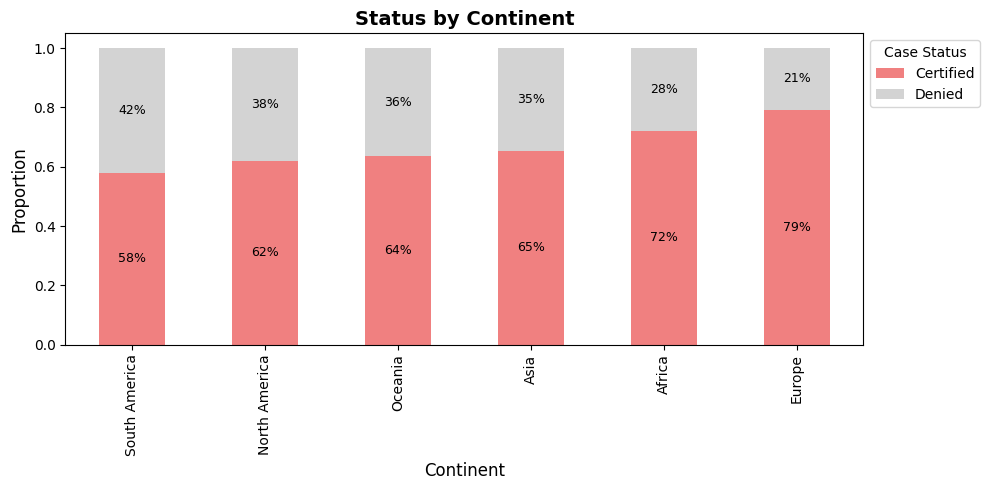

In [ ]:
stacked_barplot(df,'continent','case_status',title="Status by Continent")

Observations:

- European applicants show the highest approval rate.
- South America has the lowest approval rate.

# Insights from EDA

**Visa Approval Imbalance:**

- 67% of applications are certified and 33% are denied. This imbalance supports the need for careful model tuning and sampling strategies.

**Education Level:**

- Higher education is linked to higher approval rates. Master’s and Doctorate  degrees have 79–87% approval, while High School has the lowest (~34% certified).

**Job Experience:**

- Prior job experience is a strong positive indicator. Applicants with experience have 74% approval vs. 56% for those without.

**Job Training Requirement:**

- Applicants requiring training have only a minor difference in approval rates compared to those who don’t (68% vs. 67%).

**Region of Employment:**

- Midwest and South regions have the highest approval rates (76% and 70% respectively).

- Island region has the lowest approval rate (60%).

**Company Characteristics:**

- Number of Employees: Highly right-skewed with extreme outliers. Most companies are small.

- Year of Establishment: Most companies were established after 1980, with a few going back to the 1800s.

- Prevailing Wage: Also right-skewed with long tail. Wages >$150K are rare but exist as outliers.



# **Data Pre-processing**

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

Feature engineering (if needed)

In [ ]:
from datetime import datetime

# Current year (or year of data collection if specified, e.g., 2023)
current_year = datetime.now().year

# Create new feature: company age
df['company_age'] = current_year - df['yr_of_estab']

In [ ]:
#dropping yr of estab
df.drop('yr_of_estab', axis=1, inplace=True)

In [ ]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age
0,Asia,High School,N,N,14513,West,592.2029,Hour,Y,Denied,18
1,Asia,Master's,Y,N,2412,Northeast,83425.6500,Year,Y,Certified,23
2,Asia,Bachelor's,N,Y,44444,West,122996.8600,Year,Y,Denied,17
3,Asia,Bachelor's,N,N,98,West,83434.0300,Year,Y,Denied,128
4,Africa,Master's,Y,N,1082,South,149907.3900,Year,Y,Certified,20


Observations:

We created company_age based on the yr_of_estab column to represent how many years the company has been in existence

Outlier detection and treatment (if needed)

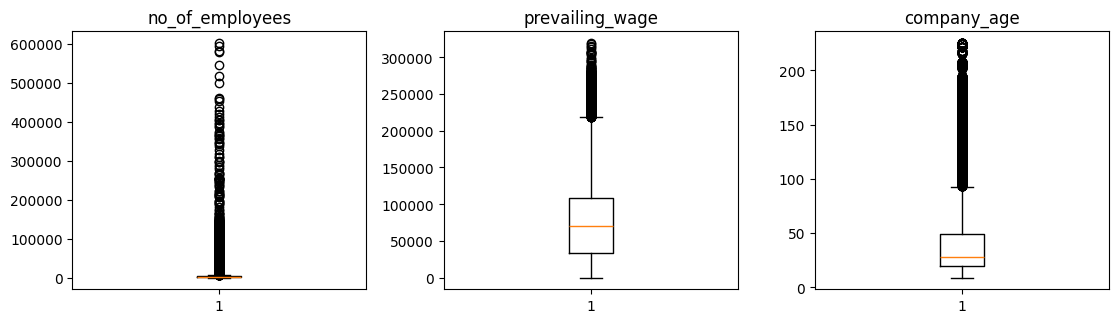

In [ ]:
# outlier detection using boxplot
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

Observations:

- There are a lot of outliers in the data. However, we will not treat them as they are proper values.

Preparing data for modeling

In [ ]:
df["case_status"] = df["case_status"].apply(lambda x: 1 if x == "Certified" else 0)

In [ ]:
X = df.drop(["case_status"], axis=1)
y = df["case_status"]


X = pd.get_dummies(X, drop_first=True)


# Splitting data into training, validation and test set:
# first we split data into 2 parts, say temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)
print(X_train.shape, X_val.shape, X_test.shape)

(15288, 21) (5096, 21) (5096, 21)


In [ ]:
print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in validation data =", X_val.shape[0])
print("Number of rows in test data =", X_test.shape[0])

Number of rows in train data = 15288
Number of rows in validation data = 5096
Number of rows in test data = 5096


In [ ]:
print("Shape of Training set : ", X_train.shape)
print("Shape of the Validation set: ", X_val.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in validation set:")
print(y_val.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (15288, 21)
Shape of the Validation set:  (5096, 21)
Shape of test set :  (5096, 21)
Percentage of classes in training set:
case_status
1    0.667844
0    0.332156
Name: proportion, dtype: float64
Percentage of classes in validation set:
case_status
1    0.667975
0    0.332025
Name: proportion, dtype: float64
Percentage of classes in test set:
case_status
1    0.667975
0    0.332025
Name: proportion, dtype: float64


Observations:

-  Roughly 66.75% of cases are class 0 and 33.25% are class 1 across all splits.



# **Model Building**

Model Evaluation Criterion
-----------------------------

**Model can make wrong predictions as:**
1. False Positive: The model predicts that a visa application will be certified, but in reality, it gets denied.

2. False Negative: The model predicts that a visa application will be denied, but in reality, it gets certified.

**Which case is more important?**
* Both the cases are important as:

* A False Positive may result in an unqualified individual receiving the visa and job opportunity, potentially displacing a qualified U.S. candidate.

* A False Negative could prevent a highly qualified foreign worker from contributing to the U.S. economy, leading to a loss of valuable talent.

* **Both errors are important and must be carefully minimized.**

**How to reduce this loss i.e need to reduce False Negatives?**
* F1 Score can be used a the metric for evaluation of the model, greater the F1 score higher are the chances of minimizing False Negatives and False Positives.

* The F1 Score provides a balanced measure of Precision and Recall, helping minimize both False Positives and False Negatives.

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

## Initial Model Building

### Model Building - Original Data

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("XGBoost", XGBClassifier( eval_metric='logloss', random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\nTraining Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores = f1_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, scores))

print("\nValidation Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores_val = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.9896098804156048
Random forest: 1.0
GBM: 0.8291218182658106
Adaboost: 0.8204269947530306
XGBoost: 0.897194519526517
dtree: 1.0

Validation Performance:

Bagging: 0.7736734095573146
Random forest: 0.7994366197183098
GBM: 0.826637008202419
Adaboost: 0.8180081855388813
XGBoost: 0.8063660477453581
dtree: 0.7458075904677847


In [ ]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_train = f1_score(y_train, model.predict(X_train))
    scores_val = f1_score(y_val, model.predict(X_val))
    difference1 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(
        name, scores_train, scores_val, difference1
    ))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9896, Validation Score: 0.7737, Difference: 0.2159
Random forest: Training Score: 1.0000, Validation Score: 0.7994, Difference: 0.2006
GBM: Training Score: 0.8291, Validation Score: 0.8266, Difference: 0.0025
Adaboost: Training Score: 0.8204, Validation Score: 0.8180, Difference: 0.0024
XGBoost: Training Score: 0.8972, Validation Score: 0.8064, Difference: 0.0908
dtree: Training Score: 1.0000, Validation Score: 0.7458, Difference: 0.2542


Observations:

- AdaBoost has the best performance followed by GBM (Gradient Boosting) and XGBoost show minimal performance gap between training and validation.



####Random Forest Classifier

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0
Testing performance:
    Accuracy    Recall  Precision        F1
0  0.711931  0.836369   0.757584  0.795029


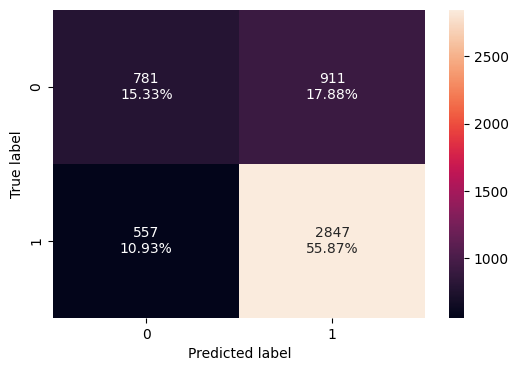

In [ ]:
#Fitting the model
rf_estimator = RandomForestClassifier(random_state=1)
rf_estimator.fit(X_train,y_train)

#Calculating different metrics
rf_estimator_model_train_perf=model_performance_classification_sklearn(rf_estimator,X_train,y_train)
print("Training performance:\n",rf_estimator_model_train_perf)
rf_estimator_model_test_perf=model_performance_classification_sklearn(rf_estimator,X_test,y_test)
print("Testing performance:\n",rf_estimator_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(rf_estimator,X_test,y_test)

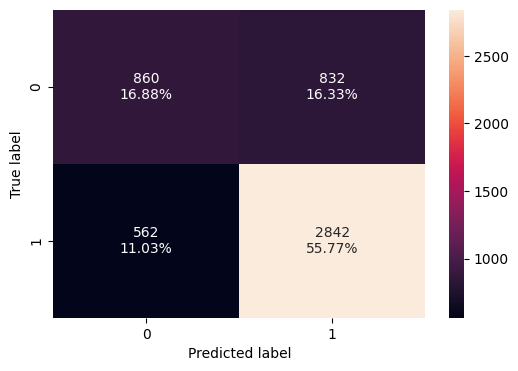

In [ ]:
# Confusion Matrix
confusion_matrix_sklearn(rf_estimator, X_val, y_val)

In [ ]:
rf_estimator_model_val_perf= model_performance_classification_sklearn(
    rf_estimator, X_val, y_val
)
rf_estimator_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.726452,0.8349,0.773544,0.803052


Observations:


Random Forest is clearly overitting the training data. A high difference in performance is observed.


####AdaBoost Classifier

Training performance:
    Accuracy    Recall  Precision        F1
0  0.740319  0.888247   0.762229  0.820427
Testing performance:
    Accuracy    Recall  Precision        F1
0  0.731947  0.883079   0.756417  0.814855


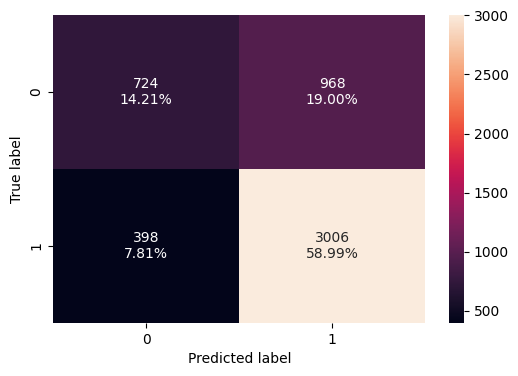

In [ ]:
#Fitting the model
ab_classifier = AdaBoostClassifier(random_state=1)
ab_classifier.fit(X_train,y_train)

#Calculating different metrics
ab_classifier_model_train_perf=model_performance_classification_sklearn(ab_classifier,X_train,y_train)
print("Training performance:\n", ab_classifier_model_train_perf)
ab_classifier_model_test_perf=model_performance_classification_sklearn(ab_classifier,X_test,y_test)
print("Testing performance:\n", ab_classifier_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(ab_classifier,X_test,y_test)

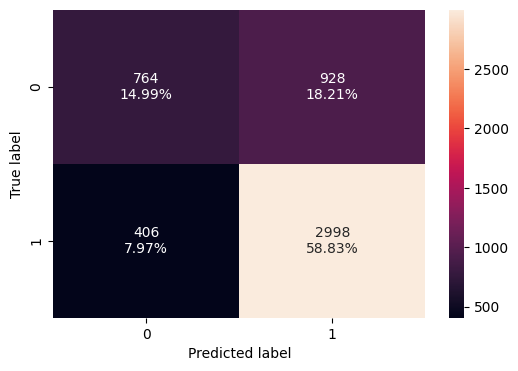

In [ ]:
# Confusion Matrix
confusion_matrix_sklearn(ab_classifier, X_val, y_val)

In [ ]:
ab_classifier_model_val_perf = model_performance_classification_sklearn(
    ab_classifier, X_val, y_val
)
ab_classifier_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.738226,0.880729,0.763627,0.818008


Observations:

AdaBoost is demonstrating good generalization with no signs of overfitting.


#### Gradient Boosting Classifier

Training performance:
    Accuracy    Recall  Precision        F1
0  0.758046  0.878942   0.784646  0.829122
Testing performance:
    Accuracy   Recall  Precision        F1
0  0.740973  0.87309   0.769948  0.818282


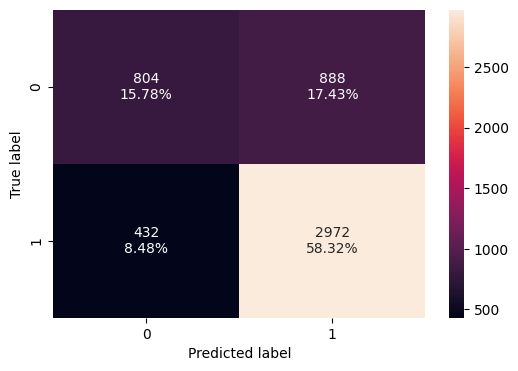

In [ ]:
#Fitting the model
gb_classifier = GradientBoostingClassifier(random_state=1)
gb_classifier.fit(X_train,y_train)

#Calculating different metrics
gb_classifier_model_train_perf=model_performance_classification_sklearn(gb_classifier,X_train,y_train)
print("Training performance:\n",gb_classifier_model_train_perf)
gb_classifier_model_test_perf=model_performance_classification_sklearn(gb_classifier,X_test,y_test)
print("Testing performance:\n",gb_classifier_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(gb_classifier,X_test,y_test)

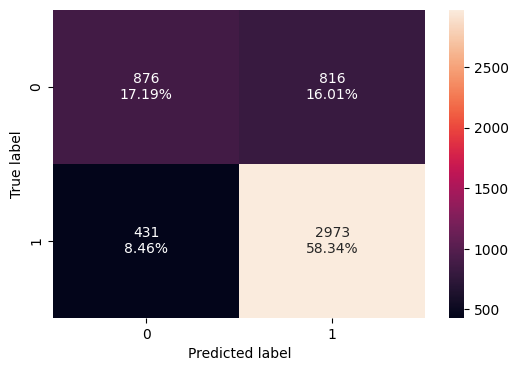

In [ ]:
# Confusion Matrix
confusion_matrix_sklearn(gb_classifier, X_val, y_val)

In [ ]:
gb_classifier_model_val_perf= model_performance_classification_sklearn(gb_classifier, X_val, y_val)
gb_classifier_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.755298,0.873384,0.78464,0.826637


Observations:

- Gradient Boosting demonstrates strong generalization with no signs of overfitting

#### XGBoost Classifier

Training performance:
    Accuracy    Recall  Precision        F1
0  0.855704  0.942801   0.855797  0.897195
Testing performance:
    Accuracy    Recall  Precision        F1
0  0.717033  0.849001   0.756941  0.800332


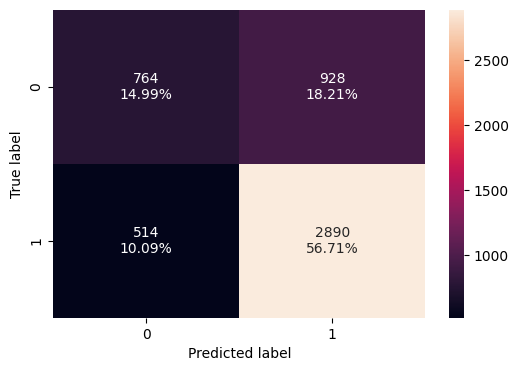

In [ ]:
#Fitting the model
xgb_classifier = XGBClassifier(random_state=1, eval_metric='logloss')
xgb_classifier.fit(X_train,y_train)

#Calculating different metrics
xgb_classifier_model_train_perf=model_performance_classification_sklearn(xgb_classifier,X_train,y_train)
print("Training performance:\n",xgb_classifier_model_train_perf)
xgb_classifier_model_test_perf=model_performance_classification_sklearn(xgb_classifier,X_test,y_test)
print("Testing performance:\n",xgb_classifier_model_test_perf)

#Creating confusion matrix
confusion_matrix_sklearn(xgb_classifier,X_test,y_test)

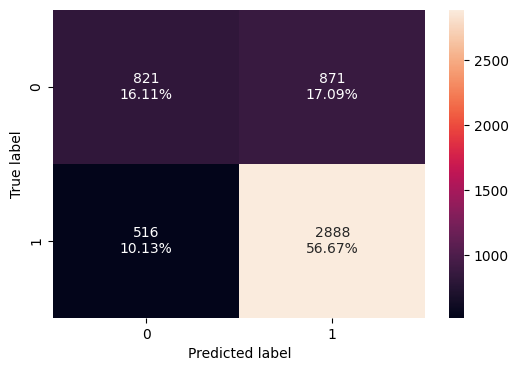

In [ ]:
# Confusion matrix
confusion_matrix_sklearn(xgb_classifier, X_val, y_val)

In [ ]:
xgb_classifier_model_val_perf = model_performance_classification_sklearn(xgb_classifier, X_val, y_val)
xgb_classifier_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.727826,0.848414,0.768289,0.806366


Observations:

- XGBoost also performed well.


####  Bagging

Training performance:
    Accuracy    Recall  Precision        F1
0  0.986329  0.987659   0.991836  0.989743
Testing performance:
    Accuracy    Recall  Precision        F1
0  0.686028  0.771445   0.761601  0.766492


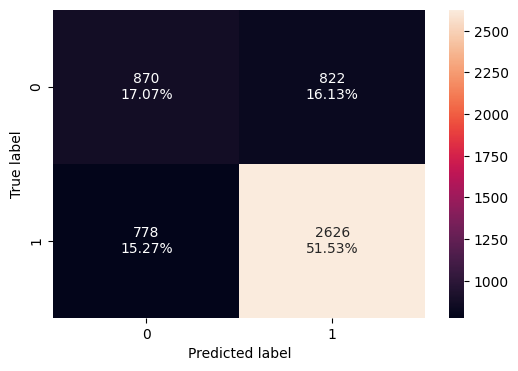

In [ ]:
# Fitting the model
bagging_classifier = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1), random_state=1)
bagging_classifier.fit(X_train, y_train)

# Calculating different metrics
bagging_classifier_model_train_perf = model_performance_classification_sklearn(bagging_classifier, X_train, y_train)
bagging_classifier_model_test_perf = model_performance_classification_sklearn(bagging_classifier, X_test, y_test)
print("Training performance:\n", bagging_classifier_model_train_perf)
print("Testing performance:\n", bagging_classifier_model_test_perf)

#  Creating confusion matrix
confusion_matrix_sklearn(bagging_classifier, X_test, y_test)

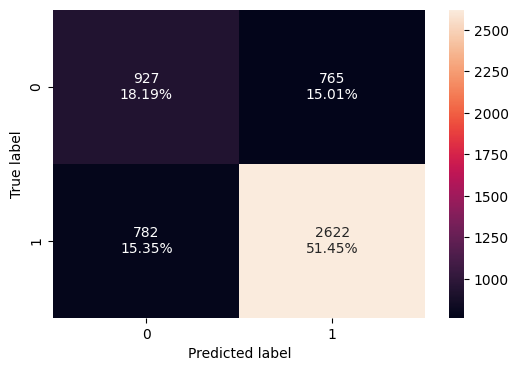

In [ ]:
# Validation confusion matrix
confusion_matrix_sklearn(bagging_classifier, X_val, y_val)

In [ ]:
# Validation metrics
bagging_classifier_model_val_perf = model_performance_classification_sklearn(bagging_classifier, X_val, y_val)
display(bagging_classifier_model_val_perf)


,Accuracy,Recall,Precision,F1
0,0.696429,0.77027,0.774136,0.772198


Observations:

Bagging is clearly overfitting the training data, as evidenced by a significant gap between training and test performance.

#### Decision Tree

Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0
Testing performance:
    Accuracy    Recall  Precision        F1
0  0.650706  0.743537   0.736184  0.739842


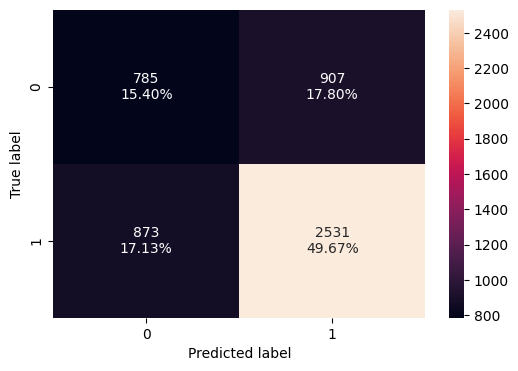

In [ ]:
# Fitting the model
dtree_classifier = DecisionTreeClassifier(random_state=1, class_weight='balanced')
dtree_classifier.fit(X_train, y_train)

#  Calculating different metrics
dtree_classifier_model_train_perf = model_performance_classification_sklearn(dtree_classifier, X_train, y_train)
dtree_classifier_model_test_perf = model_performance_classification_sklearn(dtree_classifier, X_test, y_test)
print("Training performance:\n", dtree_classifier_model_train_perf)
print("Testing performance:\n", dtree_classifier_model_test_perf)

#  Creating confusion matrix
confusion_matrix_sklearn(dtree_classifier, X_test, y_test)

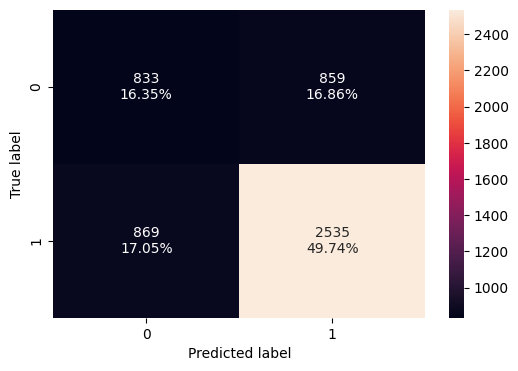

In [ ]:
#  Validation confusion matrix
confusion_matrix_sklearn(dtree_classifier, X_val, y_val)

In [ ]:
# Validation metrics
dtree_classifier_model_val_perf = model_performance_classification_sklearn(dtree_classifier, X_val, y_val)
display(dtree_classifier_model_val_perf)

,Accuracy,Recall,Precision,F1
0,0.660911,0.744712,0.746906,0.745808


Observations:

Decision Tree is clearly overitting the training data. A high difference in performance is observed.

##Model Building - Oversampled Data

In [ ]:
print("Before Oversampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Yes': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'No': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Yes': 10210
Before Oversampling, counts of label 'No': 5078 

After Oversampling, counts of label 'Yes': 10210
After Oversampling, counts of label 'No': 10210 

After Oversampling, the shape of train_X: (20420, 21)
After Oversampling, the shape of train_y: (20420,) 



In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("XGBoost", XGBClassifier(eval_metric='logloss', random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = f1_score(y_train_over, model.predict(X_train_over))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9875473741201949
Random forest: 0.9999020568070519
GBM: 0.8067991826119264
Adaboost: 0.798110661268556
XGBoost: 0.8712206047032475
dtree: 1.0

Validation Performance:

Bagging: 0.7697604790419161
Random forest: 0.7964755163946267
GBM: 0.8147937411095306
Adaboost: 0.8180684494942497
XGBoost: 0.8105515587529976
dtree: 0.7337029821669414


In [ ]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_train = f1_score(y_train_over, model.predict(X_train_over))
    scores_val = f1_score(y_val, model.predict(X_val))
    difference2 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference2))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9875, Validation Score: 0.7698, Difference: 0.2178
Random forest: Training Score: 0.9999, Validation Score: 0.7965, Difference: 0.2034
GBM: Training Score: 0.8068, Validation Score: 0.8148, Difference: -0.0080
Adaboost: Training Score: 0.7981, Validation Score: 0.8181, Difference: -0.0200
XGBoost: Training Score: 0.8712, Validation Score: 0.8106, Difference: 0.0607
dtree: Training Score: 1.0000, Validation Score: 0.7337, Difference: 0.2663


Observations:

Balanced training set improved F1 for the minority class.

GBC and AdaBoost maintain strong performance and even generalize slightly better (negative gap = validation better than training).

XGBoost shows improvement and more stability.

Bagging and RF perform similarly to original — slight improvement or stability.

Decision Tree still overfits despite balancing.

## Model Building - Undersampled Data

In [ ]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [ ]:
print("Before Under Sampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Yes': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'No': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Yes': 10210
Before Under Sampling, counts of label 'No': 5078 

After Under Sampling, counts of label 'Yes': 5078
After Under Sampling, counts of label 'No': 5078 

After Under Sampling, the shape of train_X: (10156, 21)
After Under Sampling, the shape of train_y: (10156,) 



In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("XGBoost", XGBClassifier(eval_metric='logloss', random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))


print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores_train = f1_score(y_train_un, model.predict(X_train_un))
    print("{}: {}".format(name, scores_train))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores_val = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.9800677695834163
Random forest: 1.0
GBM: 0.7281441717791411
Adaboost: 0.7015343047380103
XGBoost: 0.8720351390922401
dtree: 1.0

Validation Performance:

Bagging: 0.7067745197168858
Random forest: 0.7397481433645463
GBM: 0.776595744680851
Adaboost: 0.765990884802766
XGBoost: 0.746130524972076
dtree: 0.6899450371807306


In [ ]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores_train = f1_score(y_train_un, model.predict(X_train_un))
    scores_val = f1_score(y_val, model.predict(X_val))
    difference3 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference3))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9801, Validation Score: 0.7068, Difference: 0.2733
Random forest: Training Score: 1.0000, Validation Score: 0.7397, Difference: 0.2603
GBM: Training Score: 0.7281, Validation Score: 0.7766, Difference: -0.0485
Adaboost: Training Score: 0.7015, Validation Score: 0.7660, Difference: -0.0645
XGBoost: Training Score: 0.8720, Validation Score: 0.7461, Difference: 0.1259
dtree: Training Score: 1.0000, Validation Score: 0.6899, Difference: 0.3101


Observations:

- GBC, AdaBoost, and XGBoost show degradation in validation F1.

- Gap is larger for almost all models.

- Information loss from reducing training data hurt model learning.

- Still useful for quick baseline or low-resource environments.


- **We will tune these models using the original data because it consistently delivered better performance compared to under- or oversampled versions. The original data yielded more stable and generalizable results — making it a reliable base for hyperparameter tuning**

## Hyperparameter Tuning

# **Model Performance Improvement**

##Hyperparameter Tuning - Random Forest

In [ ]:
%%time

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score
import numpy as np

# Initialize Random Forest model
rf_tuned = RandomForestClassifier(random_state=1, oob_score=True, bootstrap=True,class_weight='balanced')

# Define hyperparameter grid
parameters = {
    "max_depth": list(np.arange(5, 15, 5)),
    "max_features": ["sqrt", "log2"],
    "min_samples_split": [3, 5, 7],
    "n_estimators": np.arange(10, 40, 10),
}

# Scorer
acc_scorer = make_scorer(f1_score)

# Randomized Search
random_obj = RandomizedSearchCV(
    estimator=rf_tuned,
    param_distributions=parameters,
    scoring=acc_scorer,
    cv=5,
    n_iter=10,  # you can adjust this
    random_state=1,
    n_jobs=-1
)

# Fit on oversampled training data
random_obj.fit(X_train, y_train)

# Update model to best estimator
rf_tuned = random_obj.best_estimator_

# Display best parameters
print("Best parameters for Random Forest:")
print(random_obj.best_params_)

# Fit the final model again on full oversampled data (optional)
rf_tuned.fit(X_train, y_train)


Best parameters for Random Forest:
{'n_estimators': np.int64(30), 'min_samples_split': 7, 'max_features': 'sqrt', 'max_depth': np.int64(10)}
CPU times: user 1.49 s, sys: 47.3 ms, total: 1.54 s
Wall time: 14.6 s


RandomForestClassifier(class_weight='balanced', max_depth=np.int64(10),
                       min_samples_split=7, n_estimators=np.int64(30),
                       oob_score=True, random_state=1)

###Checking model performance on training set

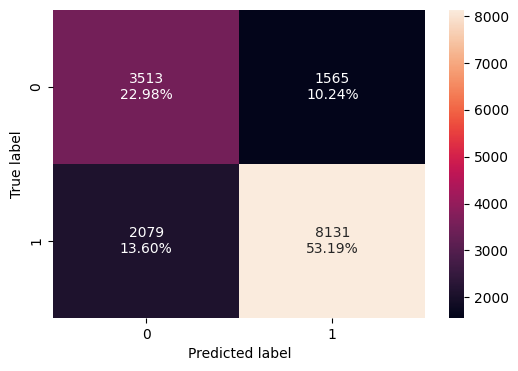

In [ ]:
confusion_matrix_sklearn(rf_tuned, X_train, y_train)

In [ ]:
rf_tuned_model_train_perf = model_performance_classification_sklearn(
    rf_tuned, X_train, y_train
)
rf_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.761643,0.796376,0.838593,0.81694


### Checking model performance on validation set

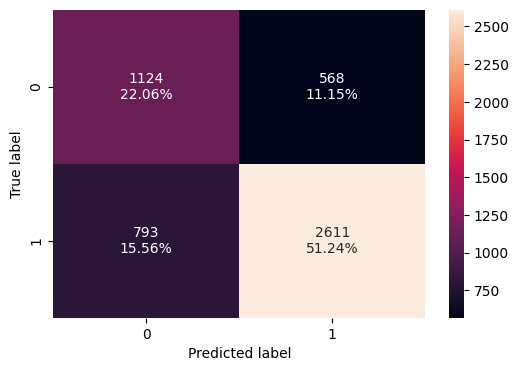

In [ ]:
confusion_matrix_sklearn(rf_tuned, X_val, y_val)

In [ ]:
rf_tuned_model_val_perf = model_performance_classification_sklearn(
    rf_tuned, X_val, y_val
)
rf_tuned_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.732928,0.767039,0.821327,0.793255


Observations:

-  F1-score of ~0.7932 on validation and 0.8969 on training, good results.


## Hyperparameter Tuning - AdaBoost Classifier

In [ ]:
%%time

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score
import numpy as np

# Initialize AdaBoost classifier
abc_tuned = AdaBoostClassifier(random_state=1)

# Define hyperparameter distributions
parameters = {
    "estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1)
    ],
    "n_estimators": np.arange(50, 150, 25),
    "learning_rate": np.arange(0.01, 0.2, 0.05),
}

# Scoring metric
acc_scorer = make_scorer(f1_score)

# Randomized search
random_obj = RandomizedSearchCV(
    estimator=abc_tuned,
    param_distributions=parameters,
    scoring=acc_scorer,
    cv=5,
    n_iter=10,  # reasonable limit
    random_state=1,
    n_jobs=-1
)

# Fit to oversampled training data
random_obj.fit(X_train, y_train)

# Retrieve best model
abc_tuned = random_obj.best_estimator_

# Print best params
print("Best Parameters for AdaBoost:")
print(random_obj.best_params_)

# Fit the final model (optional)
abc_tuned.fit(X_train, y_train)


Best Parameters for AdaBoost:
{'n_estimators': np.int64(50), 'learning_rate': np.float64(0.16000000000000003), 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)}
CPU times: user 3.61 s, sys: 140 ms, total: 3.75 s
Wall time: 1min 32s


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=np.float64(0.16000000000000003),
                   n_estimators=np.int64(50), random_state=1)

### Checking model performance on training set

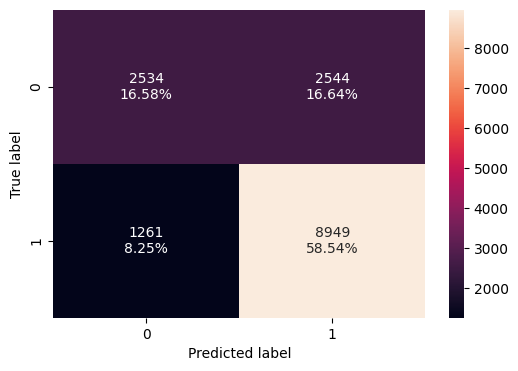

In [ ]:
# Checking model performance on training set
confusion_matrix_sklearn(abc_tuned, X_train, y_train)  # Confusion matrix




In [ ]:
abc_tuned_model_train_perf = model_performance_classification_sklearn(
    abc_tuned, X_train, y_train
)
abc_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.751112,0.876494,0.778648,0.824679


### Checking model performance on validation set

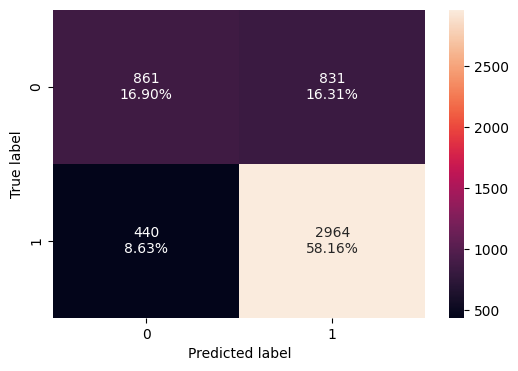

In [ ]:
# Checking model performance on validation set
confusion_matrix_sklearn(abc_tuned, X_val, y_val)  # Confusion matrix




In [ ]:
abc_tuned_model_val_perf = model_performance_classification_sklearn(
    abc_tuned, X_val, y_val
)
abc_tuned_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.750589,0.87074,0.781028,0.823448


Observations:

- F1-score remains stable between train and validation.


- Very close to the performance of the tuned Random Forest (F1 ≈ 0.8258).


## Hyperparameter Tuning - Gradient Boosting Classifier

In [ ]:
%%time

# Initialize Gradient Boosting classifier
gbc_tuned = GradientBoostingClassifier(random_state=1)

# Define hyperparameter distributions
parameters = {
    "n_estimators": np.arange(50, 150, 25),
    "subsample": [0.7, 0.9, 1.0],
    "max_features": [0.7, 0.8, 0.9, 1.0],
    "learning_rate": [0.01, 0.1, 0.05]
}

# Scoring function
acc_scorer = make_scorer(f1_score)

# Run randomized search
random_obj = RandomizedSearchCV(
    estimator=gbc_tuned,
    param_distributions=parameters,
    scoring=acc_scorer,
    cv=5,
    n_iter=10,
    random_state=1,
    n_jobs=-1
)

# Fit to oversampled training data
random_obj.fit(X_train, y_train)

# Get best model
gbc_tuned = random_obj.best_estimator_

# Display best parameters
print("Best parameters for Gradient Boosting:")
print(random_obj.best_params_)

# Fit final model (optional, already done above)
gbc_tuned.fit(X_train, y_train)

Best parameters for Gradient Boosting:
{'subsample': 0.7, 'n_estimators': np.int64(50), 'max_features': 1.0, 'learning_rate': 0.1}
CPU times: user 2.56 s, sys: 106 ms, total: 2.66 s
Wall time: 55.8 s


GradientBoostingClassifier(max_features=1.0, n_estimators=np.int64(50),
                           random_state=1, subsample=0.7)

###Checking model performance on training set

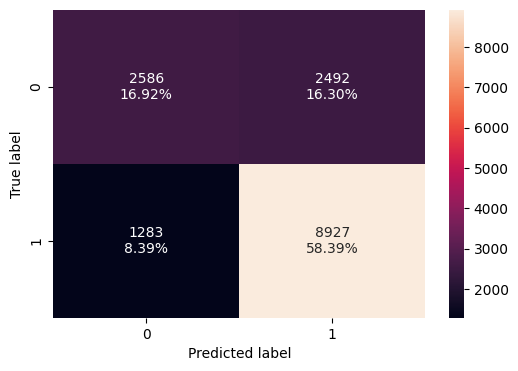

In [ ]:
# Confusion matrix for training set
confusion_matrix_sklearn(gbc_tuned,X_train, y_train)

In [ ]:
# Classification metrics
gbc_tuned_model_train_perf = model_performance_classification_sklearn(
    gbc_tuned, X_train, y_train
)
gbc_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.753074,0.874339,0.781767,0.825466


### Checking model performance on validation set

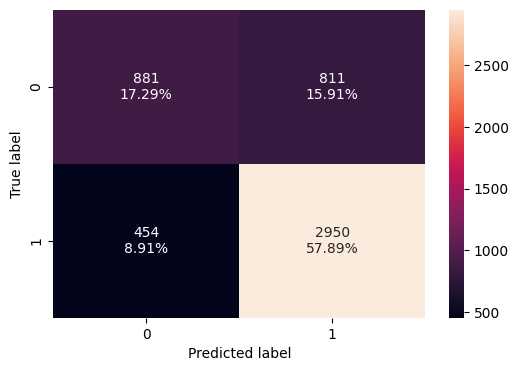

In [ ]:
# Confusion Matrix
confusion_matrix_sklearn(gbc_tuned, X_val, y_val)

In [ ]:
# Classification Performance
gbc_tuned_model_val_perf = model_performance_classification_sklearn(gbc_tuned, X_val, y_val)
gbc_tuned_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.751766,0.866627,0.784366,0.823447


Observations:

- Strong recall and precision.

- Comparable training F1 to both Random Forest (0.8432) and AdaBoost (0.8243).

- Very balanced — great at identifying the positive class with fewer false alarms.


## Hyperparameter Tuning - XGBoost Classifier

In [ ]:
%%time

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score
import numpy as np

# Initialize the classifier
xgb_tuned = XGBClassifier(random_state=1, eval_metric='logloss')

# Define the parameter distributions
parameters = {
    "n_estimators": np.arange(50, 150, 25),
    "scale_pos_weight": [1, 2, 5],
    "subsample": [0.9, 1],
    "learning_rate": [0.01, 0.1, 0.05],
    "gamma": [1, 3]
}

# Scorer
acc_scorer = make_scorer(f1_score)

# Randomized Search
random_obj = RandomizedSearchCV(
    estimator=xgb_tuned,
    param_distributions=parameters,
    scoring=acc_scorer,
    cv=5,
    n_iter=10,
    random_state=1,
    n_jobs=-1
)

# Fit the search on oversampled data
random_obj.fit(X_train, y_train)

# Get the best estimator
xgb_tuned = random_obj.best_estimator_

# Print best parameters
print("Best parameters for XGBoost:")
print(random_obj.best_params_)

# Fit again to the full training data (optional)
xgb_tuned.fit(X_train, y_train)


Best parameters for XGBoost:
{'subsample': 0.9, 'scale_pos_weight': 1, 'n_estimators': np.int64(50), 'learning_rate': 0.05, 'gamma': 1}
CPU times: user 934 ms, sys: 37.5 ms, total: 971 ms
Wall time: 11.5 s


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=np.int64(50), n_jobs=None,
              num_parallel_tree=None, ...)

### Checking model performance on training set

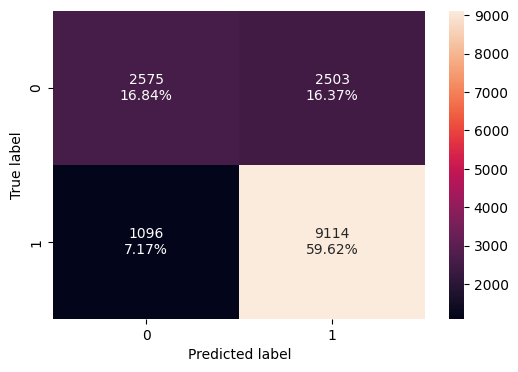

In [ ]:
# Confusion matrix
confusion_matrix_sklearn(xgb_tuned, X_train, y_train)

In [ ]:
# Classification metrics
xgb_tuned_model_train_perf = model_performance_classification_sklearn(xgb_tuned, X_train, y_train)
xgb_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.764587,0.892654,0.78454,0.835112


### Checking model performance on validation set

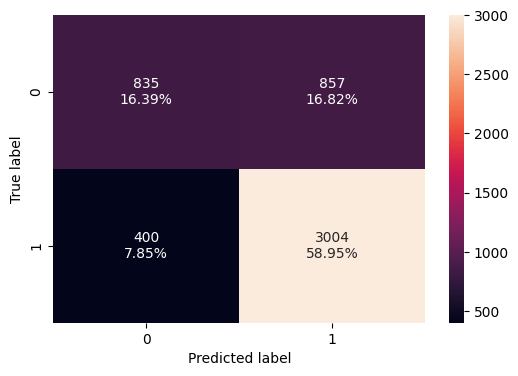

In [ ]:
# Confusion matrix
confusion_matrix_sklearn(xgb_tuned, X_val, y_val)

In [ ]:
# Classification metrics
xgb_tuned_model_val_perf = model_performance_classification_sklearn(xgb_tuned, X_val, y_val)
xgb_tuned_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.753336,0.882491,0.778037,0.826979


Observations:

- Very high recall — excellent at detecting positive class (certified).

- Balanced precision and F1-score, suggesting good model learning

## Hyperparameter Tuning - Bagging Classifier

In [ ]:
%%time
# Initialize the base model
bagging_model = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1), random_state=1)

# Define parameter distributions
param_dist_bagging = {
    'max_samples': [0.8, 0.9, 1],
    'max_features': [0.7, 0.8, 0.9],
    'n_estimators': [30, 50, 70]
}

# Define scorer
acc_scorer = make_scorer(f1_score)

# RandomizedSearchCV
bagging_search = RandomizedSearchCV(
    estimator=bagging_model,
    param_distributions=param_dist_bagging,
    scoring=acc_scorer,
    cv=5,
    n_iter=10,
    random_state=1,
    n_jobs=-1
)

# Fit on oversampled data
bagging_search.fit(X_train, y_train)

# Best model
bagging_tuned = bagging_search.best_estimator_

# Print best params
print("Best parameters for Bagging:", bagging_search.best_params_)

# Fit the final model again (optional)
bagging_tuned.fit(X_train, y_train)

Best parameters for Bagging: {'n_estimators': 70, 'max_samples': 0.9, 'max_features': 0.8}
CPU times: user 9.83 s, sys: 178 ms, total: 10 s
Wall time: 1min 45s


BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1),
                  max_features=0.8, max_samples=0.9, n_estimators=70,
                  random_state=1)

### Check Performance for Tuned Bagging Classifier

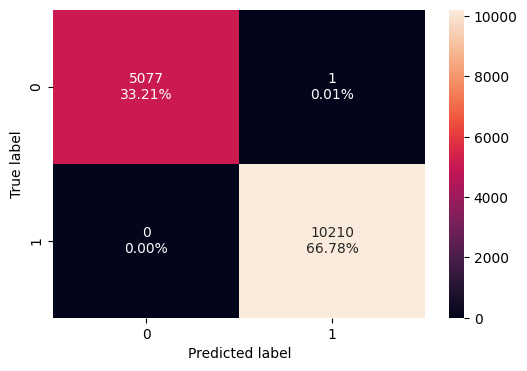

In [ ]:
# Confusion Matrix
confusion_matrix_sklearn(bagging_tuned, X_train, y_train)

In [ ]:
# Classification Metrics
bagging_tuned_model_train_perf = model_performance_classification_sklearn(bagging_tuned, X_train, y_train)
bagging_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.999935,1.0,0.999902,0.999951


### Checking model performance on validation set

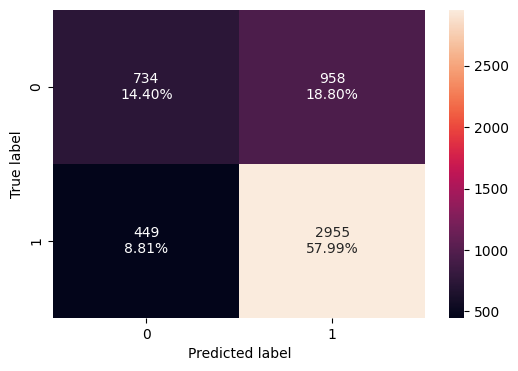

In [ ]:
# Confusion Matrix
confusion_matrix_sklearn(bagging_tuned, X_val, y_val)

In [ ]:
# Classification Metrics
bagging_tuned_model_val_perf = model_performance_classification_sklearn(bagging_tuned, X_val, y_val)
bagging_tuned_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.723901,0.868096,0.755175,0.807708


Observations:

- The bagging tuned is overfitted, as we can appreciate the high diferences in the Train and validation performance.

## Hyperparameter Tuning - Decision Tree

In [ ]:
%%time
# Base model
dtree_model = DecisionTreeClassifier(random_state=1, class_weight='balanced')

# Recommended parameter grid from the assignment
param_grid_dtree = {
    'max_depth': np.arange(2, 6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes': [10, 15],
    'min_impurity_decrease': [0.0001, 0.001]

}

# F1 scorer
acc_scorer = make_scorer(f1_score)

# Randomized search CV
dtree_grid = RandomizedSearchCV(
    dtree_model,
    param_distributions=param_grid_dtree,
    scoring=acc_scorer,
    n_iter=10,   # Optional: set based on how broad the search should be
    cv=5,
    n_jobs=-1,
    random_state=1
)

# Fit to oversampled or appropriate training data
dtree_grid.fit(X_train, y_train)

# Best model and parameters
dtree_tuned = dtree_grid.best_estimator_
print("Best parameters for Decision Tree:", dtree_grid.best_params_)

Best parameters for Decision Tree: {'min_samples_leaf': 7, 'min_impurity_decrease': 0.0001, 'max_leaf_nodes': 15, 'max_depth': np.int64(5)}
CPU times: user 171 ms, sys: 17.2 ms, total: 188 ms
Wall time: 1.65 s


### Check Performance for Tuned Bagging Classifier

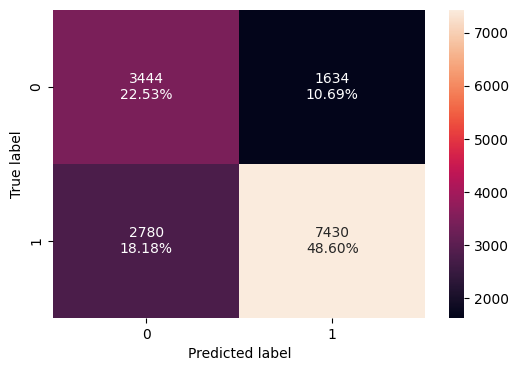

In [ ]:
# Confusion Matrix
confusion_matrix_sklearn(dtree_tuned, X_train, y_train)


In [ ]:
# Classification Metrics
dtree_tuned_model_train_perf = model_performance_classification_sklearn(dtree_tuned, X_train, y_train)
dtree_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.711277,0.727718,0.819726,0.770987


### Checking model performance on validation set

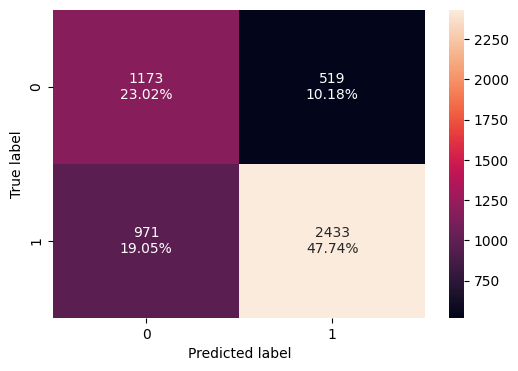

In [ ]:
# Confusion Matrix
confusion_matrix_sklearn(dtree_tuned, X_val, y_val)

In [ ]:
# Classification Metrics
dtree_tuned_model_val_perf = model_performance_classification_sklearn(dtree_tuned, X_val, y_val)
dtree_tuned_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.707614,0.714747,0.824187,0.765576


Observations:

- The tuned decision tree is not overfitting the dataset.

# **Model Comparison and Final Model Selection**

In [ ]:
# Performance comparison for tuned models only
models_tuned_comp_df = pd.concat(
    [
        rf_tuned_model_train_perf.T,
        abc_tuned_model_train_perf.T,
        gbc_tuned_model_train_perf.T,
        xgb_tuned_model_train_perf.T,
        bagging_tuned_model_train_perf.T,
        dtree_tuned_model_train_perf.T,
    ],
    axis=1,
)

models_tuned_comp_df.columns = [
    "Tuned Random Forest",
    "Tuned AdaBoost Classifier",
    "Tuned Gradient Boost Classifier",
    "Tuned XGBoost Classifier",
    "Tuned Bagging Classifier",
    "Tuned Decision Tree Classifier",
]

print("Training Performance Comparison - Tuned Models Only:")
models_tuned_comp_df


Training Performance Comparison - Tuned Models Only:


,Tuned Random Forest,Tuned AdaBoost Classifier,Tuned Gradient Boost Classifier,Tuned XGBoost Classifier,Tuned Bagging Classifier,Tuned Decision Tree Classifier
Accuracy,0.761643,0.751112,0.753074,0.764587,0.999935,0.711277
Recall,0.796376,0.876494,0.874339,0.892654,1.000000,0.727718
Precision,0.838593,0.778648,0.781767,0.784540,0.999902,0.819726
F1,0.816940,0.824679,0.825466,0.835112,0.999951,0.770987


Observations:

- Bagging Is Severely Overfitting

- XGBoost Is Best Overall
  High recall (0.8927), solid precision (0.7845), and F1-score (0.8351).

- Random Forest Has Strong Training Power Slight risk of overfitting


- GBC and AdaBoost Are Reliable.
  Both show balanced metrics

- Decision Tree aceptable F1.

In [ ]:
# Validation performance comparison for tuned models only
models_val_comp_df = pd.concat(
    [
        rf_tuned_model_val_perf.T,
        abc_tuned_model_val_perf.T,
        gbc_tuned_model_val_perf.T,
        xgb_tuned_model_val_perf.T,
        bagging_tuned_model_val_perf.T,
        dtree_tuned_model_val_perf.T,
    ],
    axis=1,
)

models_val_comp_df.columns = [
    "Tuned Random Forest",
    "Tuned AdaBoost Classifier",
    "Tuned Gradient Boost Classifier",
    "Tuned XGBoost Classifier",
    "Tuned Bagging Classifier",
    "Tuned Decision Tree Classifier",
]

print("Validation Performance Comparison - Tuned Models Only:")
models_val_comp_df



Validation Performance Comparison - Tuned Models Only:


,Tuned Random Forest,Tuned AdaBoost Classifier,Tuned Gradient Boost Classifier,Tuned XGBoost Classifier,Tuned Bagging Classifier,Tuned Decision Tree Classifier
Accuracy,0.732928,0.750589,0.751766,0.753336,0.723901,0.707614
Recall,0.767039,0.870740,0.866627,0.882491,0.868096,0.714747
Precision,0.821327,0.781028,0.784366,0.778037,0.755175,0.824187
F1,0.793255,0.823448,0.823447,0.826979,0.807708,0.765576


Observations:

1. XGBoost Is Best Overall
Highest F1-score, highest accuracy, and second-best recall.

Best balance of power and generalization across all metrics.

2. Decision Tree Performs good lower metrics similar to Random Forest.

Very lightweight and interpretable.


3. GBC and AdaBoost Are balanced metrics, good results.




In [ ]:
#Printing test performance
rf_tuned_model_test_perf = model_performance_classification_sklearn(rf_tuned, X_test, y_test)
abc_tuned_model_test_perf = model_performance_classification_sklearn(abc_tuned, X_test, y_test)
gbc_tuned_model_test_perf = model_performance_classification_sklearn(gbc_tuned, X_test, y_test)
xgb_tuned_model_test_perf = model_performance_classification_sklearn(xgb_tuned, X_test, y_test)
bagging_tuned_model_test_perf = model_performance_classification_sklearn(bagging_tuned, X_test, y_test)
dtree_tuned_model_test_perf   = model_performance_classification_sklearn(dtree_tuned, X_test, y_test)

In [ ]:
# Test performance comparison for tuned models only
models_test_comp_df = pd.concat(
    [
        rf_tuned_model_test_perf.T,
        abc_tuned_model_test_perf.T,
        gbc_tuned_model_test_perf.T,
        xgb_tuned_model_test_perf.T,
        bagging_tuned_model_test_perf.T,
        dtree_tuned_model_test_perf.T,
    ],
    axis=1,
)

models_test_comp_df.columns = [
    "Tuned Random Forest",
    "Tuned AdaBoost Classifier",
    "Tuned Gradient Boost Classifier",
    "Tuned XGBoost Classifier",
    "Tuned Bagging Classifier",
    "Tuned Decision Tree Classifier",
]

print("Test Performance Comparison - Tuned Models Only:")
models_test_comp_df

Test Performance Comparison - Tuned Models Only:


,Tuned Random Forest,Tuned AdaBoost Classifier,Tuned Gradient Boost Classifier,Tuned XGBoost Classifier,Tuned Bagging Classifier,Tuned Decision Tree Classifier
Accuracy,0.719584,0.740188,0.740385,0.742543,0.719780,0.706240
Recall,0.770564,0.873972,0.871034,0.881904,0.866921,0.732374
Precision,0.801895,0.768734,0.770330,0.767382,0.751656,0.809678
F1,0.785918,0.817982,0.817593,0.820667,0.805184,0.769088


Observations:

- XGBoost is the Winner
 Best F1 Score (0.8207)  and best recall.

 Reliable and consistent across training, validation, and test.

- Random Forest and Decision tree lower f1.

- Adaboost and gradient sencond and third best performance.

-  Bagging good performance.


,Accuracy,Recall,Precision,F1
0,0.742543,0.881904,0.767382,0.820667


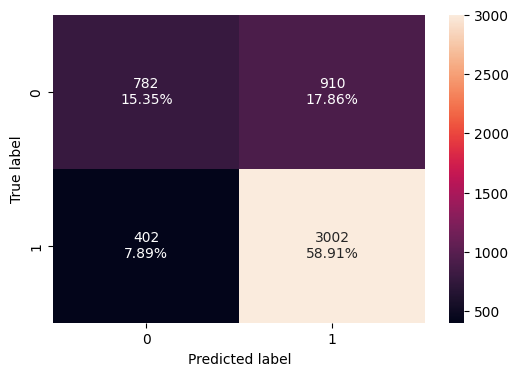

In [ ]:
# performance of best model on test set
final_model = xgb_tuned
confusion_matrix_sklearn(final_model, X_test, y_test)

final_model_test_perf = model_performance_classification_sklearn(final_model, X_test, y_test)
final_model_test_perf

Observations:

- **Final Model: Tuned XGBoost Classifier**

High recall (0.8819): Model correctly identifies ~88% of actual positive cases (Certified).

F1-score (0.8207): Best among all models — confirms excellent balance between precision and recall.

Strong generalization: Minimal performance drop from validation → test, confirming model reliability.

- **Best F1-score Balanced model performance**

   

##Important features of the final model

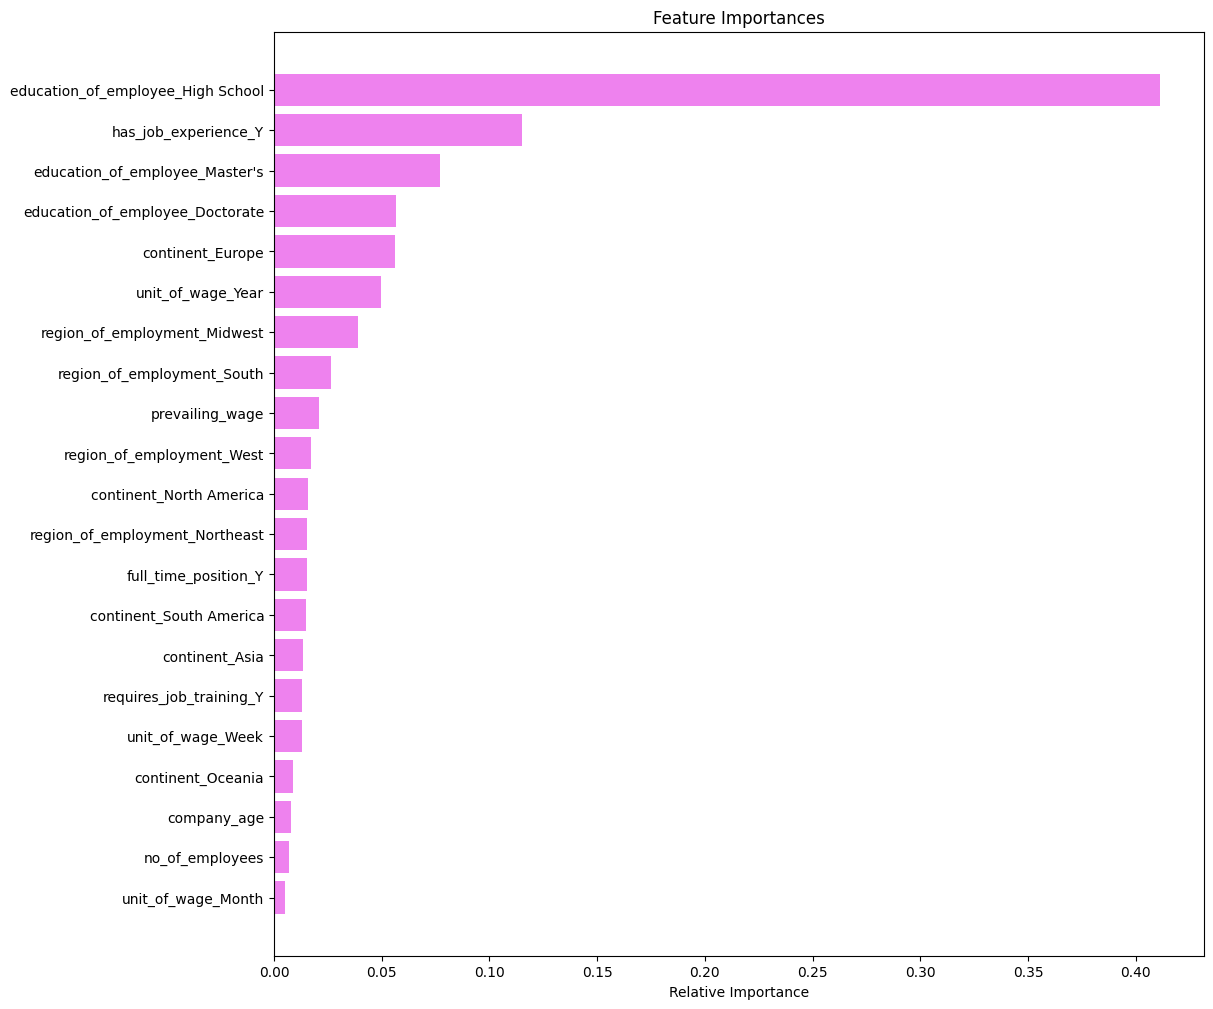

In [ ]:
# Feature importance from the final selected model
feature_names = X_train.columns
importances = final_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()


Observations:

1. **Education is the most influential factor:**

Especially having only a high school degree negatively impacts approval.

Higher education (Master’s, Doctorate) improves chances.

2. **Experience matters:**

Previous job experience (has_job_experience_Y) is a top positive predictor.

3. **Geography & Wage:**

Both the continent of origin and employment region influence approval likelihood.

Wage type and amount contribute meaningfully.

4. **Company characteristics** play a minor role compared to applicant features.



# **Actionable Insights and Recommendations**

 **Response to Objective:**
To support OFLC to help in shortlisting the candidates having higher chances of VISA Approval, We developed and evaluated multiple classifications models on the dataset to predict whether a visa application would be **Certified** or **Denied**.


**Model Development Summary**

* Data Preparation: Explored original, undersampled, and oversampled versions.
Final tuning and evaluation were performed on the original dataset due to its superior generalizability and stable performance.

*Algorithms Evaluated:

Decision Tree

Random Forest

Gradient Boosting (GBM)

XGBoost

AdaBoost

Bagging



* Model Evaluation: F1 Score.


**Final Model Selection**

* Selected Model: Tuned XGBoost Classifier

Justification:

Strong generalization across validation and test sets.

Test F1 Score: 0.8207

Test Recall: 0.8819



 ## **Actionable Insights**

1. **Top Factors Influencing Visa Approval:**

- education_of_employee_High School (strongest predictor)

- has_job_experience_Y

- education_of_employee_Master's, Doctorate

- prevailing_wage

- unit_of_wage_Year

- region_of_employment and continent

2. **Visa Approval Is More Likely When:**

- The applicant has prior job experience

- The applicant has either a high school degree or a Master’s/Doctorate

- Employment is based in North America or Europe

- The employer is in the Midwest/South/West region of the U.S.

## **Recommendations**

1. Automated Screening System:

   Deploy the XGBoost model to identify high-likelihood visa approvals.

   Prioritize human review for borderline or low-confidence predictions.

2. Profile Optimization Tool:

   Provide feedback to applicants on how factors like education level, wage expectations, and experience impact their chances.

3. Focus on High-Impact Features

  Streamline policies around education level, wage structure, and job experience.

4. Promote Educational Advancement (Master’s or Doctorate)

   Data shows:

   87% approval for Doctorate

   79% approval for Master’s

   Lower approval if only High School and no job experience
   

___

In [ ]:
#lets check the columns of the xgb tuned model
xgb_tuned.get_booster().feature_names


['no_of_employees',
 'prevailing_wage',
 'company_age',
 'continent_Asia',
 'continent_Europe',
 'continent_North America',
 'continent_Oceania',
 'continent_South America',
 'education_of_employee_Doctorate',
 'education_of_employee_High School',
 "education_of_employee_Master's",
 'has_job_experience_Y',
 'requires_job_training_Y',
 'region_of_employment_Midwest',
 'region_of_employment_Northeast',
 'region_of_employment_South',
 'region_of_employment_West',
 'unit_of_wage_Month',
 'unit_of_wage_Week',
 'unit_of_wage_Year',
 'full_time_position_Y']

In [ ]:
df['education_of_employee'].unique()

array(['High School', "Master's", "Bachelor's", 'Doctorate'], dtype=object)

In [ ]:
import pickle

# Save your best trained model (xgb_tuned)
with open("easyvisa_xgb_model.pkl", "wb") as f:
    pickle.dump(xgb_tuned, f)


In [ ]:
# Save the column names after pd.get_dummies (order matters!)
with open("easyvisa_train_columns.pkl", "wb") as f:
    pickle.dump(list(X_train.columns), f)


In [ ]:
from google.colab import files
files.download("easyvisa_xgb_model.pkl")
files.download("easyvisa_train_columns.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#download the plk model
from google.colab import files
files.download("easyvisa_xgb_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive/Project_EasyVisa_3_F1"

ls: cannot access '/content/drive/MyDrive/Project_EasyVisa_3_F1': No such file or directory


In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/Project_EasyVisa_3_F1.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Project_EasyVisa_3_F1.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 60 image(s).
[NbConvertApp] Writing 3130530 bytes to /content/drive/MyDrive/Colab Notebooks/Project_EasyVisa_3_F1.html


In [ ]:
from google.colab import files
files.download("/content/drive/MyDrive/Colab Notebooks/Project_EasyVisa_3_F1.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
categorical_cols = [
    'continent',
    'education_of_employee',
    'has_job_experience',
    'requires_job_training',
    'region_of_employment',
    'unit_of_wage',
    'full_time_position'
]

for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")


continent: ['Asia' 'Africa' 'North America' 'Europe' 'South America' 'Oceania']
education_of_employee: ['High School' "Master's" "Bachelor's" 'Doctorate']
has_job_experience: ['N' 'Y']
requires_job_training: ['N' 'Y']
region_of_employment: ['West' 'Northeast' 'South' 'Midwest' 'Island']
unit_of_wage: ['Hour' 'Year' 'Week' 'Month']
full_time_position: ['Y' 'N']


In [ ]:
label_map = {1: "Certified", 0: "Denied"}


In [ ]:
y_pred = xgb_tuned.predict(X_test)


In [ ]:
import pandas as pd

compare = pd.DataFrame({
    'Actual_Status': pd.Series(y_test).reset_index(drop=True).map(label_map),
    'Predicted_Status': pd.Series(y_pred).reset_index(drop=True).map(label_map)
})

print(compare.head(10))


  Actual_Status Predicted_Status
0     Certified        Certified
1     Certified        Certified
2        Denied           Denied
3     Certified           Denied
4        Denied           Denied
5     Certified        Certified
6     Certified        Certified
7        Denied        Certified
8        Denied        Certified
9     Certified        Certified


In [ ]:
label_map = {1: "Certified", 0: "Denied"}

# Get predictions
y_pred = xgb_tuned.predict(X_test)

# Build a DataFrame from X_test (reset index to align everything)
result_df = X_test.reset_index(drop=True).copy()
result_df['Actual_Status'] = pd.Series(y_test).reset_index(drop=True).map(label_map)
result_df['Predicted_Status'] = pd.Series(y_pred).reset_index(drop=True).map(label_map)

# Show first 10 rows (or as many as you want)
print(result_df.head(10))


   no_of_employees  prevailing_wage  company_age  continent_Asia  \
0              287       72125.4600           20            True   
1              708      110222.4900           20            True   
2             1524       72723.4900           97            True   
3             3928         516.5046           52           False   
4             3081      107725.6900           25            True   
5             1195      108519.1400          111            True   
6             2091       60321.9700           77            True   
7             1242      152320.2800           27            True   
8              831       66198.5900           26            True   
9             1821      101044.6000           57            True   

   continent_Europe  continent_North America  continent_Oceania  \
0             False                    False              False   
1             False                    False              False   
2             False                    False      

In [ ]:
print(df['continent'].unique())
print(df['education_of_employee'].unique())
# ...and so on for each categorical variable


['Asia' 'Africa' 'North America' 'Europe' 'South America' 'Oceania']
['High School' "Master's" "Bachelor's" 'Doctorate']


In [ ]:
print(df['region_of_employment'].unique())
print(df['unit_of_wage'].unique())
print(df['has_job_experience'].unique())
print(df['requires_job_training'].unique())
print(df['full_time_position'].unique())


['West' 'Northeast' 'South' 'Midwest' 'Island']
['Hour' 'Year' 'Week' 'Month']
['N' 'Y']
['N' 'Y']
['Y' 'N']


In [ ]:
print(X_test.iloc[0])


no_of_employees                           287
prevailing_wage                      72125.46
company_age                                20
continent_Asia                           True
continent_Europe                        False
continent_North America                 False
continent_Oceania                       False
continent_South America                 False
education_of_employee_Doctorate         False
education_of_employee_High School       False
education_of_employee_Master's          False
has_job_experience_Y                    False
requires_job_training_Y                  True
region_of_employment_Midwest            False
region_of_employment_Northeast          False
region_of_employment_South               True
region_of_employment_West               False
unit_of_wage_Month                      False
unit_of_wage_Week                       False
unit_of_wage_Year                        True
full_time_position_Y                     True
Name: 6726, dtype: object
